# Aftenposten Content Analysis — Plots & Analysis

**Research Question:** Did the Stoltenberg appointment reprime the 2025
Norwegian election around security and competence?

Three observation periods:

- **BEFORE** — ~2 weeks before Stoltenberg appointment (mid-Jan to Feb 3, 2025)
- **AFTER** — ~2 weeks after appointment (Feb 5 to ~Feb 20, 2025)
- **ELECTION** — ~2 weeks before election day (late Aug to Sep 8, 2025)


In [116]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import warnings

warnings.filterwarnings("ignore")

# =============================================================================
# LOAD CLEANED DATA
# =============================================================================
OUTPUT_DIR = Path("../data/output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load the CSV produced by parse_aftenposten.py
CSV_PATH = OUTPUT_DIR / "aftenposten_analysis_sample.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["date"])
print(f"Loaded {len(df)} articles from {CSV_PATH}")

# If the period column wasn't computed with the ELECTION window, recompute it
# --- Adjust these dates to match your actual data ---
TREATMENT_DATE = pd.Timestamp("2025-02-04")
BEFORE_START = pd.Timestamp("2025-01-13")
BEFORE_END = pd.Timestamp("2025-02-03")
AFTER_START = pd.Timestamp("2025-02-05")
AFTER_END = pd.Timestamp("2025-02-21")
ELECT_START = pd.Timestamp("2025-08-18")
ELECT_END = pd.Timestamp("2025-09-08")


def assign_period(d):
    if pd.isna(d):
        return "UNKNOWN"
    if BEFORE_START <= d <= BEFORE_END:
        return "BEFORE"
    if AFTER_START <= d <= AFTER_END:
        return "AFTER"
    if ELECT_START <= d <= ELECT_END:
        return "ELECTION"
    if d == TREATMENT_DATE:
        return "TREATMENT_DAY"
    return "OUTSIDE"


df["period"] = df["date"].apply(assign_period)

# Issue groups
ISSUE_GROUPS = {
    "FrP-owned": ["IMM", "ECON"],
    "Labour-owned": [
        "SEC",
        "GOV",
    ],
    "Contested": ["TAX"],
    "Left-niche": ["CLI", "GAZ", "HEA"],
    "Other": ["OTH"],
}
CODE_TO_GROUP = {}
for g, codes in ISSUE_GROUPS.items():
    for c in codes:
        CODE_TO_GROUP[c] = g
df["issue_group"] = df["issue_code"].map(CODE_TO_GROUP).fillna("Other")

# Boolean flags (ensure they exist)
for col in ["mentions_stoltenberg", "mentions_listhaug", "mentions_solberg"]:
    if col in df.columns:
        flag = "flag_" + col.replace("mentions_", "")
        df[flag] = df[col].astype(str).str.upper() == "YES"

# Build analysis sample: only the three periods, only Norway-related
PERIOD_ORDER = ["BEFORE", "AFTER", "ELECTION"]
dfa = df[df["period"].isin(PERIOD_ORDER)].copy()

print(f"\nAnalysis sample: {len(dfa)} articles")
for p in PERIOD_ORDER:
    n = (dfa["period"] == p).sum()
    print(f"  {p}: {n}")

Loaded 753 articles from ../data/output/aftenposten_analysis_sample.csv

Analysis sample: 672 articles
  BEFORE: 234
  AFTER: 216
  ELECTION: 222


## Filter: keep only articles concerning Norway


In [117]:
""" if "concerns_norway" in dfa.columns:
    n_before = len(dfa)
    removed = dfa[dfa["concerns_norway"].astype(str).str.upper() != "YES"]
    dfa = dfa[dfa["concerns_norway"].astype(str).str.upper() == "YES"].copy()
    n_after = len(dfa)
    print(
        f"Filtered: {n_before} → {n_after} articles ({n_before - n_after} non-Norway removed)"
    )
    if len(removed) > 0:
        print(f"  Removed articles:")
        for _, r in removed.iterrows():
            print(
                f"    [{r.get('date', '?')}] {r.get('headline_en', r.get('headline_no', '?'))[:80]}"
            )
else:
    print("No 'concerns_norway' column found — keeping all articles.")
 """

' if "concerns_norway" in dfa.columns:\n    n_before = len(dfa)\n    removed = dfa[dfa["concerns_norway"].astype(str).str.upper() != "YES"]\n    dfa = dfa[dfa["concerns_norway"].astype(str).str.upper() == "YES"].copy()\n    n_after = len(dfa)\n    print(\n        f"Filtered: {n_before} → {n_after} articles ({n_before - n_after} non-Norway removed)"\n    )\n    if len(removed) > 0:\n        print(f"  Removed articles:")\n        for _, r in removed.iterrows():\n            print(\n                f"    [{r.get(\'date\', \'?\')}] {r.get(\'headline_en\', r.get(\'headline_no\', \'?\'))[:80]}"\n            )\nelse:\n    print("No \'concerns_norway\' column found — keeping all articles.")\n '

## Expand dataset to include secondary issue codes

Insert this cell right after `dfa` is created (before any charts).
It "melts" each article into one or two rows — one per issue code.
All downstream charts and tables will automatically reflect both codes.


In [118]:
# ======================================================
# CONFIGURATION — how to handle dual-coded articles
# ======================================================
USE_SECONDARY_CODES = True  # Set to False to revert to primary-only

# Weighting scheme for dual-coded articles:
#   "equal"   → each code gets weight 1.0 (article counted twice)
#              → percentages = "% of articles touching this issue"
#   "split"   → primary gets 0.67, secondary gets 0.33
#              → preserves total weight = 1 per article
#   "primary_heavy" → primary gets 1.0, secondary gets 0.5
#              → secondary contributes but primary dominates
WEIGHTING = "equal"
# ======================================================

VALID_ISSUE_CODES = {"IMM", "ECON", "SEC", "GOV", "TAX", "GAZ", "CLI", "HEA", "OTH"}

if USE_SECONDARY_CODES:
    rows = []
    for _, article in dfa.iterrows():
        # Primary code — always included
        row1 = article.copy()
        row1["code_source"] = "primary"
        if WEIGHTING == "equal":
            row1["weight"] = 1.0
        elif WEIGHTING == "split":
            has_secondary = (
                isinstance(article.get("issue_code_2"), str)
                and article["issue_code_2"].strip()
                and article["issue_code_2"] in VALID_ISSUE_CODES
            )
            row1["weight"] = 0.67 if has_secondary else 1.0
        elif WEIGHTING == "primary_heavy":
            row1["weight"] = 1.0
        rows.append(row1)

        # Secondary code — only if valid and non-empty
        code2 = article.get("issue_code_2", "")
        if (
            isinstance(code2, str)
            and code2.strip()
            and code2.strip() in VALID_ISSUE_CODES
        ):
            row2 = article.copy()
            row2["issue_code"] = code2.strip()
            row2["issue_group"] = CODE_TO_GROUP.get(code2.strip(), "Other")
            row2["code_source"] = "secondary"
            if WEIGHTING == "equal":
                row2["weight"] = 1.0
            elif WEIGHTING == "split":
                row2["weight"] = 0.33
            elif WEIGHTING == "primary_heavy":
                row2["weight"] = 0.5
            rows.append(row2)

    dfa_expanded = pd.DataFrame(rows).reset_index(drop=True)

    # Stats
    n_original = len(dfa)
    n_expanded = len(dfa_expanded)
    n_dual = n_expanded - n_original
    pct_dual = n_dual / n_original * 100 if n_original > 0 else 0

    print(
        f"Expanded dataset: {n_original} articles → {n_expanded} rows "
        f"({n_dual} secondary codes added, {pct_dual:.0f}% of articles are dual-coded)"
    )
    print(f"Weighting scheme: {WEIGHTING}")

    # Replace dfa so all downstream code uses the expanded version
    dfa_primary_only = dfa.copy()  # keep a backup
    dfa = dfa_expanded

    # Recompute the shared crosstabs used by all charts
    # (these are the same lines from analyze_aftenposten.py)
    if WEIGHTING == "equal":
        # Unweighted crosstabs (since weight=1 for all)
        group_pct = (
            pd.crosstab(dfa["issue_group"], dfa["period"], normalize="columns")
            .reindex(columns=PERIOD_ORDER)
            .fillna(0)
            * 100
        )
        code_pct = (
            pd.crosstab(dfa["issue_code"], dfa["period"], normalize="columns")
            .reindex(columns=PERIOD_ORDER)
            .fillna(0)
            * 100
        )
    else:
        # Weighted crosstabs
        def weighted_crosstab(df, row_col, col_col, weight_col, columns_order):
            ct = df.groupby([row_col, col_col])[weight_col].sum().unstack(fill_value=0)
            ct = ct.reindex(columns=columns_order).fillna(0)
            ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
            return ct_pct

        group_pct = weighted_crosstab(
            dfa, "issue_group", "period", "weight", PERIOD_ORDER
        )
        code_pct = weighted_crosstab(
            dfa, "issue_code", "period", "weight", PERIOD_ORDER
        )

    period_has_data = {p: (dfa["period"] == p).sum() > 0 for p in PERIOD_ORDER}

    print(f"\nUpdated crosstabs. Period counts (expanded):")
    for p in PERIOD_ORDER:
        n = (dfa["period"] == p).sum()
        n_orig = (dfa_primary_only["period"] == p).sum()
        print(f"  {p}: {n} rows (from {n_orig} articles)")

else:
    dfa["weight"] = 1.0
    dfa["code_source"] = "primary"
    print("Secondary codes: DISABLED (primary only).")
    print("Set USE_SECONDARY_CODES = True to include them.")


Expanded dataset: 672 articles → 1100 rows (428 secondary codes added, 64% of articles are dual-coded)
Weighting scheme: equal

Updated crosstabs. Period counts (expanded):
  BEFORE: 405 rows (from 234 articles)
  AFTER: 333 rows (from 216 articles)
  ELECTION: 362 rows (from 222 articles)


## Statistical Analysis of Content Analysis Results

This module runs formal statistical tests on your Aftenposten coding data.

**What we test:**

1.  Is the overall issue distribution significantly different across periods? (Chi-squared / Fisher)
2.  Are specific issue groups (FrP-owned, Labour-owned) significantly different BEFORE vs AFTER? (Z-test for proportions)
3.  How large are the effects? (Cramér's V, odds ratios, confidence intervals)
4.  Are leader mention rates significantly different? (Z-test)
5.  Is the tone shift significant? (Chi-squared)


In [119]:
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, norm
from itertools import combinations
import warnings

warnings.filterwarnings("ignore")

In [120]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================


def proportion_ztest(count1, n1, count2, n2):
    """Two-sample Z-test for difference in proportions.
    Returns z-statistic, p-value (two-sided), and 95% CI for the difference."""
    p1 = count1 / n1 if n1 > 0 else 0
    p2 = count2 / n2 if n2 > 0 else 0
    diff = p1 - p2

    # Pooled proportion under H0
    p_pool = (count1 + count2) / (n1 + n2) if (n1 + n2) > 0 else 0

    # Standard error
    se = (
        np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
        if (n1 > 0 and n2 > 0 and 0 < p_pool < 1)
        else 0
    )

    if se == 0:
        return 0, 1.0, (0, 0)

    z = diff / se
    p_value = 2 * (1 - norm.cdf(abs(z)))

    # 95% CI for the difference (unpooled SE for CI)
    se_ci = (
        np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2) if (n1 > 0 and n2 > 0) else 0
    )
    ci_low = diff - 1.96 * se_ci
    ci_high = diff + 1.96 * se_ci

    return z, p_value, (ci_low, ci_high)


def cramers_v(contingency_table):
    """Cramér's V effect size for a contingency table.
    V ≈ 0.1 small, 0.3 medium, 0.5 large."""
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    if min_dim == 0 or n == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))


def odds_ratio(a, b, c, d):
    """Odds ratio from a 2x2 table: [[a,b],[c,d]].
    OR > 1 means the event is more likely in group 1."""
    if b == 0 or c == 0:
        return float("inf") if a * d > 0 else 0
    return (a * d) / (b * c)


def format_p(p):
    """Format p-value for display."""
    if p < 0.001:
        return "p < 0.001 ***"
    elif p < 0.01:
        return f"p = {p:.3f} **"
    elif p < 0.05:
        return f"p = {p:.3f} *"
    elif p < 0.10:
        return f"p = {p:.3f} †"
    else:
        return f"p = {p:.3f}"


def sig_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.10:
        return "†"
    else:
        return ""


print("Statistical functions loaded.\n")


Statistical functions loaded.



### Test 1 — Overall association between period and issue distribution

**H₀:** Issue distribution is independent of period (no priming effect).
**H₁:** Issue distribution depends on period (priming occurred).

We use **Chi-squared test** if expected cell counts are ≥ 5, otherwise **Fisher's exact test** (or Monte Carlo approximation).


In [121]:
print("=" * 70)
print("TEST 1: Overall issue distribution × period")
print("=" * 70)

# Build contingency table: issue_code × period
period_pairs = [("BEFORE", "AFTER"), ("BEFORE", "ELECTION"), ("AFTER", "ELECTION")]

for p1, p2 in period_pairs:
    sub = dfa[dfa["period"].isin([p1, p2])]
    if sub.empty or sub["period"].nunique() < 2:
        print(f"\n  {p1} vs {p2}: skipped (insufficient data)")
        continue

    ct = pd.crosstab(sub["issue_code"], sub["period"])

    # Check expected cell counts
    chi2, p_val, dof, expected = chi2_contingency(ct)
    min_expected = expected.min()
    pct_low = (expected < 5).sum() / expected.size * 100

    print(f"\n  {p1} vs {p2}:")
    print(
        f"    Sample: {len(sub)} observations ({(sub['period'] == p1).sum()} vs {(sub['period'] == p2).sum()})"
    )
    print(f"    Chi-squared = {chi2:.2f}, df = {dof}, {format_p(p_val)}")
    print(f"    Cramér's V = {cramers_v(ct):.3f}", end="")
    v = cramers_v(ct)
    if v < 0.1:
        print(" (negligible effect)")
    elif v < 0.3:
        print(" (small effect)")
    elif v < 0.5:
        print(" (medium effect)")
    else:
        print(" (large effect)")

    if pct_low > 20:
        print(
            f"    ⚠ {pct_low:.0f}% of cells have expected count < 5 → interpret Chi-squared with caution."
        )
        print(
            f"      Consider Fisher's exact test or collapsing categories (see Test 2)."
        )


TEST 1: Overall issue distribution × period

  BEFORE vs AFTER:
    Sample: 738 observations (405 vs 333)
    Chi-squared = 13.75, df = 8, p = 0.089 †
    Cramér's V = 0.136 (small effect)

  BEFORE vs ELECTION:
    Sample: 767 observations (405 vs 362)
    Chi-squared = 19.29, df = 8, p = 0.013 *
    Cramér's V = 0.159 (small effect)

  AFTER vs ELECTION:
    Sample: 695 observations (333 vs 362)
    Chi-squared = 23.90, df = 8, p = 0.002 **
    Cramér's V = 0.185 (small effect)


### Test 2 — FrP-owned and Labour-owned issue shares by period

This is the **core hypothesis test**.
We compare the proportion of articles in each issue group
between periods using a **two-sample Z-test for proportions**.

This test is appropriate even with moderate sample sizes (~30+).


In [122]:
print("\n" + "=" * 70)
print("TEST 2: Issue group proportions — pairwise period comparisons")
print("=" * 70)

results_rows = []

for group_name in ["FrP-owned", "Labour-owned", "Contested", "Left-niche"]:
    print(f"\n  --- {group_name} ---")

    for p1, p2 in period_pairs:
        sub1 = dfa[dfa["period"] == p1]
        sub2 = dfa[dfa["period"] == p2]
        n1, n2 = len(sub1), len(sub2)

        if n1 == 0 or n2 == 0:
            continue

        count1 = (sub1["issue_group"] == group_name).sum()
        count2 = (sub2["issue_group"] == group_name).sum()
        prop1 = count1 / n1 * 100
        prop2 = count2 / n2 * 100

        z, p_val, (ci_lo, ci_hi) = proportion_ztest(count1, n1, count2, n2)

        # Odds ratio (2x2: group vs not-group × period1 vs period2)
        a, b = count1, n1 - count1  # period 1: in group, not in group
        c, d = count2, n2 - count2  # period 2: in group, not in group
        oratio = odds_ratio(a, b, c, d)

        print(
            f"    {p1} vs {p2}:  {prop1:.1f}% vs {prop2:.1f}%  "
            f"(Δ = {prop1 - prop2:+.1f}pp)  z = {z:.2f}  {format_p(p_val)}  "
            f"OR = {oratio:.2f}"
        )

        results_rows.append(
            {
                "Group": group_name,
                "Comparison": f"{p1} vs {p2}",
                f"{p1} %": round(prop1, 1),
                f"{p2} %": round(prop2, 1),
                "Δ (pp)": round(prop1 - prop2, 1),
                "z": round(z, 2),
                "p-value": round(p_val, 4),
                "Sig.": sig_stars(p_val),
                "Odds Ratio": round(oratio, 2),
                "95% CI (diff)": f"[{ci_lo * 100:.1f}, {ci_hi * 100:.1f}]",
            }
        )

df_results = pd.DataFrame(results_rows)
print("\n  Summary table:")
print(df_results.to_string(index=False))


TEST 2: Issue group proportions — pairwise period comparisons

  --- FrP-owned ---
    BEFORE vs AFTER:  22.0% vs 17.4%  (Δ = +4.6pp)  z = 1.54  p = 0.123  OR = 1.34
    BEFORE vs ELECTION:  22.0% vs 13.3%  (Δ = +8.7pp)  z = 3.15  p = 0.002 **  OR = 1.84
    AFTER vs ELECTION:  17.4% vs 13.3%  (Δ = +4.2pp)  z = 1.52  p = 0.128  OR = 1.38

  --- Labour-owned ---
    BEFORE vs AFTER:  45.7% vs 40.8%  (Δ = +4.8pp)  z = 1.32  p = 0.187  OR = 1.22
    BEFORE vs ELECTION:  45.7% vs 45.6%  (Δ = +0.1pp)  z = 0.03  p = 0.978  OR = 1.00
    AFTER vs ELECTION:  40.8% vs 45.6%  (Δ = -4.7pp)  z = -1.26  p = 0.208  OR = 0.82

  --- Contested ---
    BEFORE vs AFTER:  2.0% vs 0.6%  (Δ = +1.4pp)  z = 1.61  p = 0.108  OR = 3.34
    BEFORE vs ELECTION:  2.0% vs 3.6%  (Δ = -1.6pp)  z = -1.37  p = 0.171  OR = 0.54
    AFTER vs ELECTION:  0.6% vs 3.6%  (Δ = -3.0pp)  z = -2.71  p = 0.007 **  OR = 0.16

  --- Left-niche ---
    BEFORE vs AFTER:  16.3% vs 19.8%  (Δ = -3.5pp)  z = -1.24  p = 0.214  OR = 0.79


In [123]:
print("\n" + "=" * 70)
print("TEST 3: Individual issue codes — pairwise period comparisons")
print("=" * 70)

all_issue_rows = []

for p1, p2 in period_pairs:
    sub1 = dfa[dfa["period"] == p1]
    sub2 = dfa[dfa["period"] == p2]
    n1, n2 = len(sub1), len(sub2)

    if n1 == 0 or n2 == 0:
        print(f"\n  {p1} vs {p2}: skipped (insufficient data)")
        continue

    print(f"\n  {p1} (n={n1}) vs {p2} (n={n2}):")

    pair_rows = []
    for code in sorted(dfa["issue_code"].unique()):
        c1 = (sub1["issue_code"] == code).sum()
        c2 = (sub2["issue_code"] == code).sum()
        pct1 = c1 / n1 * 100
        pct2 = c2 / n2 * 100
        z, p_val, (ci_lo, ci_hi) = proportion_ztest(c1, n1, c2, n2)

        row = {
            "Comparison": f"{p1} vs {p2}",
            "Issue": code,
            f"{p1} (n)": c1,
            f"{p1} (%)": round(pct1, 1),
            f"{p2} (n)": c2,
            f"{p2} (%)": round(pct2, 1),
            "Δ (pp)": round(pct2 - pct1, 1),
            "z": round(z, 2),
            "p-value": round(p_val, 4),
            "Sig.": sig_stars(p_val),
        }
        pair_rows.append(row)
        all_issue_rows.append(row)

    df_pair = pd.DataFrame(pair_rows).sort_values("Δ (pp)", ascending=False)
    print(df_pair.drop(columns="Comparison").to_string(index=False))

df_all_issues = pd.DataFrame(all_issue_rows)
df_all_issues.to_csv(OUTPUT_DIR / "statistical_tests_issue_codes.csv", index=False)
print(f"\n  Saved to {OUTPUT_DIR}/statistical_tests_issue_codes.csv")



TEST 3: Individual issue codes — pairwise period comparisons

  BEFORE (n=405) vs AFTER (n=333):
Issue  BEFORE (n)  BEFORE (%)  AFTER (n)  AFTER (%)  Δ (pp)     z  p-value Sig.
  OTH          57        14.1         71       21.3     7.2 -2.59   0.0097   **
  CLI          15         3.7         20        6.0     2.3 -1.46   0.1431     
  HEA          41        10.1         36       10.8     0.7 -0.30   0.7612     
  GAZ          10         2.5         10        3.0     0.5 -0.44   0.6567     
  SEC          70        17.3         56       16.8    -0.5  0.17   0.8667     
  TAX           8         2.0          2        0.6    -1.4  1.61   0.1080     
  IMM          22         5.4         13        3.9    -1.5  0.97   0.3311     
 ECON          67        16.5         45       13.5    -3.0  1.14   0.2537     
  GOV         115        28.4         80       24.0    -4.4  1.34   0.1802     

  BEFORE (n=405) vs ELECTION (n=362):
Issue  BEFORE (n)  BEFORE (%)  ELECTION (n)  ELECTION (%)  Δ (p

In [124]:
print("\n" + "=" * 70)
print("TEST 4: Leader mention rates by period")
print("=" * 70)

for leader in ["stoltenberg", "listhaug", "solberg"]:
    flag_col = f"flag_{leader}"
    if flag_col not in dfa.columns:
        continue

    print(f"\n  --- {leader.title()} ---")
    for p1, p2 in period_pairs:
        s1 = dfa[dfa["period"] == p1]
        s2 = dfa[dfa["period"] == p2]
        n1, n2 = len(s1), len(s2)
        if n1 == 0 or n2 == 0:
            continue

        c1 = s1[flag_col].sum()
        c2 = s2[flag_col].sum()
        z, p_val, (ci_lo, ci_hi) = proportion_ztest(int(c1), n1, int(c2), n2)

        print(
            f"    {p1} vs {p2}:  {c1 / n1 * 100:.1f}% vs {c2 / n2 * 100:.1f}%  "
            f"(Δ = {c1 / n1 * 100 - c2 / n2 * 100:+.1f}pp)  z = {z:.2f}  {format_p(p_val)}"
        )



TEST 4: Leader mention rates by period

  --- Stoltenberg ---
    BEFORE vs AFTER:  2.0% vs 11.4%  (Δ = -9.4pp)  z = -5.28  p < 0.001 ***
    BEFORE vs ELECTION:  2.0% vs 9.4%  (Δ = -7.4pp)  z = -4.51  p < 0.001 ***
    AFTER vs ELECTION:  11.4% vs 9.4%  (Δ = +2.0pp)  z = 0.87  p = 0.383

  --- Listhaug ---
    BEFORE vs AFTER:  3.7% vs 4.5%  (Δ = -0.8pp)  z = -0.55  p = 0.584
    BEFORE vs ELECTION:  3.7% vs 9.7%  (Δ = -6.0pp)  z = -3.34  p < 0.001 ***
    AFTER vs ELECTION:  4.5% vs 9.7%  (Δ = -5.2pp)  z = -2.63  p = 0.008 **

  --- Solberg ---
    BEFORE vs AFTER:  2.7% vs 7.2%  (Δ = -4.5pp)  z = -2.86  p = 0.004 **
    BEFORE vs ELECTION:  2.7% vs 8.0%  (Δ = -5.3pp)  z = -3.29  p < 0.001 ***
    AFTER vs ELECTION:  7.2% vs 8.0%  (Δ = -0.8pp)  z = -0.40  p = 0.690


In [125]:
print("\n" + "=" * 70)
print("TEST 5: Tone toward Labour × period")
print("=" * 70)

if "tone_ap" in dfa.columns:
    for p1, p2 in period_pairs:
        sub = dfa[dfa["period"].isin([p1, p2])]
        sub_tone = sub[sub["tone_ap"].isin(["POS", "NEU", "NEG"])]
        if sub_tone.empty or sub_tone["period"].nunique() < 2:
            continue

        ct_tone = pd.crosstab(sub_tone["tone_ap"], sub_tone["period"])
        chi2, p_val, dof, expected = chi2_contingency(ct_tone)
        v = cramers_v(ct_tone)

        print(f"\n  {p1} vs {p2}:")
        print(f"    Chi-squared = {chi2:.2f}, df = {dof}, {format_p(p_val)}")
        print(f"    Cramér's V = {v:.3f}", end="")
        if v < 0.1:
            print(" (negligible)")
        elif v < 0.3:
            print(" (small)")
        elif v < 0.5:
            print(" (medium)")
        else:
            print(" (large)")

        # Specific: proportion of POSITIVE coverage
        for tone_val in ["POS", "NEG"]:
            s1 = sub_tone[sub_tone["period"] == p1]
            s2 = sub_tone[sub_tone["period"] == p2]
            c1 = (s1["tone_ap"] == tone_val).sum()
            c2 = (s2["tone_ap"] == tone_val).sum()
            z, pv, _ = proportion_ztest(c1, len(s1), c2, len(s2))
            print(
                f"    {tone_val} coverage: {c1 / len(s1) * 100:.1f}% vs {c2 / len(s2) * 100:.1f}%  "
                f"z = {z:.2f}  {format_p(pv)}"
            )



TEST 5: Tone toward Labour × period

  BEFORE vs AFTER:
    Chi-squared = 1.35, df = 2, p = 0.510
    Cramér's V = 0.043 (negligible)
    POS coverage: 8.9% vs 6.9%  z = 0.99  p = 0.323
    NEG coverage: 8.1% vs 9.6%  z = -0.70  p = 0.486

  BEFORE vs ELECTION:
    Chi-squared = 0.59, df = 2, p = 0.744
    Cramér's V = 0.028 (negligible)
    POS coverage: 8.9% vs 10.2%  z = -0.63  p = 0.530
    NEG coverage: 8.1% vs 7.2%  z = 0.50  p = 0.616

  AFTER vs ELECTION:
    Chi-squared = 3.45, df = 2, p = 0.178
    Cramér's V = 0.070 (negligible)
    POS coverage: 6.9% vs 10.2%  z = -1.55  p = 0.120
    NEG coverage: 9.6% vs 7.2%  z = 1.16  p = 0.248


In [126]:
print("\n" + "=" * 70)
print("RESULTS SUMMARY FOR PAPER")
print("=" * 70)

if len(df_results) > 0:
    # Focus on the key BEFORE vs AFTER comparison
    key = df_results[df_results["Comparison"] == "BEFORE vs AFTER"].copy()
    if not key.empty:
        print("\n  Key finding (BEFORE vs AFTER):\n")
        print(
            key[
                [
                    "Group",
                    "BEFORE %",
                    "AFTER %",
                    "Δ (pp)",
                    "z",
                    "p-value",
                    "Sig.",
                    "Odds Ratio",
                ]
            ].to_string(index=False)
        )

        frp_row = key[key["Group"] == "FrP-owned"]
        lab_row = key[key["Group"] == "Labour-owned"]

        if not frp_row.empty and not lab_row.empty:
            print(
                f"\n  → FrP-owned issues went from {frp_row.iloc[0]['BEFORE %']}% "
                f"to {frp_row.iloc[0]['AFTER %']}% "
                f"({frp_row.iloc[0]['Δ (pp)']:+.1f}pp, {format_p(frp_row.iloc[0]['p-value'])})"
            )
            print(
                f"  → Labour-owned issues went from {lab_row.iloc[0]['BEFORE %']}% "
                f"to {lab_row.iloc[0]['AFTER %']}% "
                f"({lab_row.iloc[0]['Δ (pp)']:+.1f}pp, {format_p(lab_row.iloc[0]['p-value'])})"
            )

    df_results.to_csv(OUTPUT_DIR / "statistical_tests_results.csv", index=False)
    print(f"\n  Full results saved to {OUTPUT_DIR}/statistical_tests_results.csv")



RESULTS SUMMARY FOR PAPER

  Key finding (BEFORE vs AFTER):

       Group  BEFORE %  AFTER %  Δ (pp)     z  p-value Sig.  Odds Ratio
   FrP-owned      22.0     17.4     4.6  1.54   0.1229             1.34
Labour-owned      45.7     40.8     4.8  1.32   0.1871             1.22
   Contested       2.0      0.6     1.4  1.61   0.1080             3.34
  Left-niche      16.3     19.8    -3.5 -1.24   0.2139             0.79

  → FrP-owned issues went from 22.0% to 17.4% (+4.6pp, p = 0.123)
  → Labour-owned issues went from 45.7% to 40.8% (+4.8pp, p = 0.187)

  Full results saved to ../data/output/statistical_tests_results.csv


In [127]:
# =============================================================================
# SCIENCES PO STYLE
# =============================================================================
SCPO_RED = "#E6142D"
SCPO_DARKGREY = "#333333"
SCPO_MIDGREY = "#6B6B6B"
SCPO_LIGHTGREY = "#E8E8E8"
SCPO_OFFWHITE = "#F7F7F7"

PAL = {
    "red": "#E6142D",
    "blue_dark": "#1B3A5C",
    "blue": "#2E6B9E",
    "blue_light": "#6BAED6",
    "teal": "#3A9E8F",
    "orange": "#E8853A",
    "gold": "#D4A843",
    "grey": "#9E9E9E",
    "pink": "#D4707A",
}

PERIOD_COLORS = {"BEFORE": PAL["blue_dark"], "AFTER": SCPO_RED, "ELECTION": PAL["teal"]}
PERIOD_LABELS = {
    "BEFORE": "Before\n(Jan 2025)",
    "AFTER": "After Stoltenberg\n(Feb 2025)",
    "ELECTION": "Pre-election\n(Aug–Sep 2025)",
}

GROUP_COLORS = {
    "FrP-owned": "#C0392B",
    "Labour-owned": "#2E6B9E",
    "Contested": "#27AE60",
    "Left-niche": "#8E44AD",
    "Other": "#BDC3C7",
}

ISSUE_LABELS = {
    "IMM": "Immigration\n& Crime",
    "ECON": "Cost-of-living\n& Energy",
    "SEC": "Security\n& Defence",
    "GOV": "Governance\n& Leadership",
    "TAX": "Wealth tax\n& Inequality",
    "GAZ": "Gaza &\nSov. Fund",
    "CLI": "Climate\n& Oil",
    "HEA": "Health\n& Welfare",
    "OTH": "Other",
}

plt.rcParams.update(
    {
        "figure.facecolor": SCPO_OFFWHITE,
        "axes.facecolor": SCPO_OFFWHITE,
        "axes.edgecolor": SCPO_LIGHTGREY,
        "axes.labelcolor": SCPO_DARKGREY,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlecolor": SCPO_DARKGREY,
        "axes.labelsize": 11,
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": SCPO_LIGHTGREY,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.7,
        "xtick.color": SCPO_MIDGREY,
        "ytick.color": SCPO_MIDGREY,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "text.color": SCPO_DARKGREY,
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.facecolor": SCPO_OFFWHITE,
        "legend.frameon": False,
        "legend.fontsize": 9,
    }
)


def add_watermark(fig):
    fig.text(
        0.98,
        0.01,
        "Sciences Po — Democracy, Parties & Elections in Europe",
        ha="right",
        va="bottom",
        fontsize=6.5,
        color=SCPO_MIDGREY,
        style="italic",
        alpha=0.6,
    )


def add_source(ax, extra=""):
    txt = "Source: Author's coding of Aftenposten (Nyheter section), Jan–Sep 2025."
    if extra:
        txt += " " + extra
    ax.annotate(
        txt,
        xy=(0, -0.18),
        xycoords="axes fraction",
        fontsize=7,
        color=SCPO_MIDGREY,
        style="italic",
    )


In [128]:
# =============================================================================
# Precompute shared crosstabs
# =============================================================================
group_pct = (
    pd.crosstab(dfa["issue_group"], dfa["period"], normalize="columns")
    .reindex(columns=PERIOD_ORDER)
    .fillna(0)
    * 100
)

code_pct = (
    pd.crosstab(dfa["issue_code"], dfa["period"], normalize="columns")
    .reindex(columns=PERIOD_ORDER)
    .fillna(0)
    * 100
)

period_has_data = {p: (dfa["period"] == p).sum() > 0 for p in PERIOD_ORDER}

print("\nPrecomputed tables ready. Generating charts...\n")


Precomputed tables ready. Generating charts...



## Figure 1 — Issue Group Shift (grouped bars)


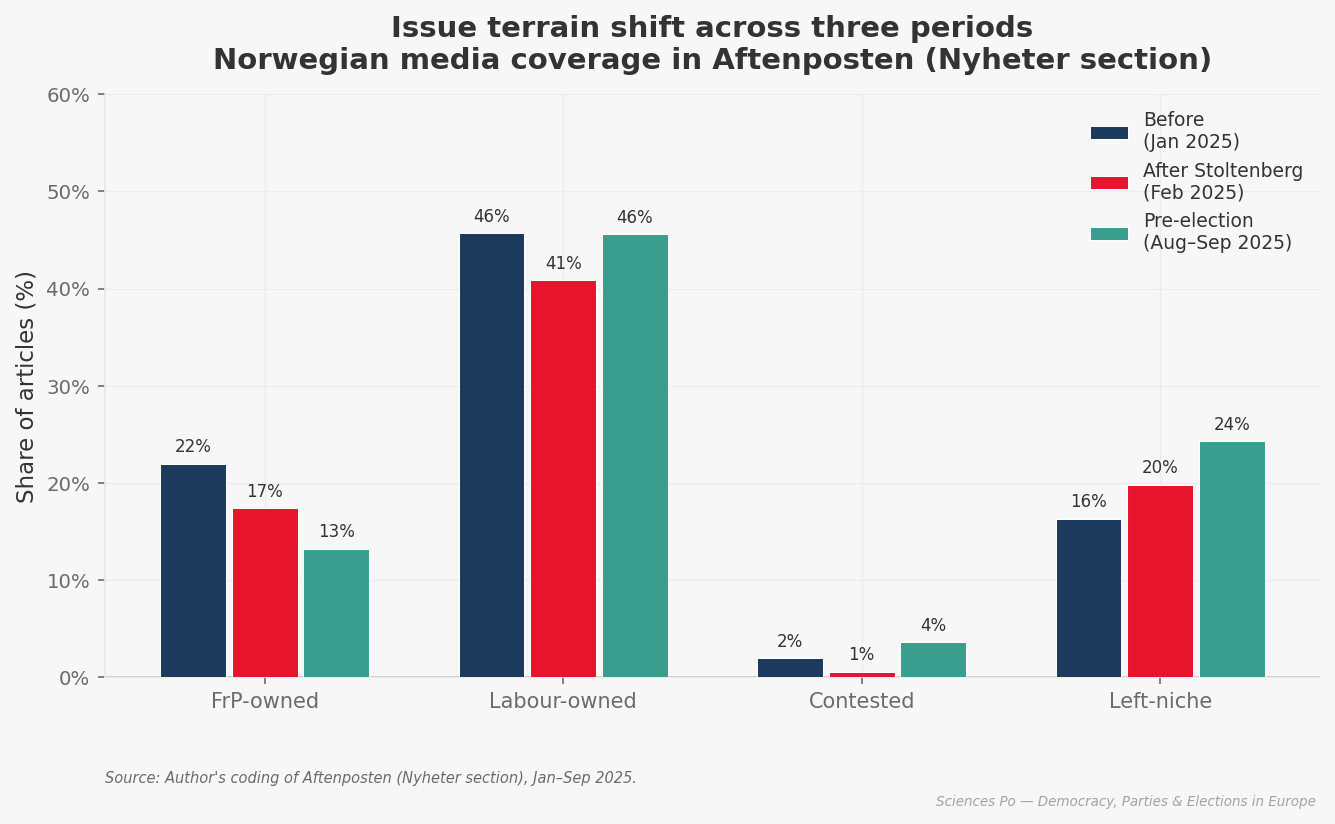

In [129]:
groups_show = ["FrP-owned", "Labour-owned", "Contested", "Left-niche"]
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(groups_show))
width = 0.24

for i, period in enumerate(PERIOD_ORDER):
    if not period_has_data[period]:
        continue
    vals = [
        group_pct.loc[g, period] if g in group_pct.index else 0 for g in groups_show
    ]
    bars = ax.bar(
        x + (i - 1) * width,
        vals,
        width * 0.92,
        label=PERIOD_LABELS[period],
        color=PERIOD_COLORS[period],
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.8,
                f"{h:.0f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                color=SCPO_DARKGREY,
                fontweight="medium",
            )

ax.set_xticks(x)
ax.set_xticklabels(groups_show, fontsize=10)
ax.set_ylabel("Share of articles (%)")
ax.set_title(
    "Issue terrain shift across three periods\n"
    "Norwegian media coverage in Aftenposten (Nyheter section)",
    pad=12,
)
ax.set_ylim(0, max(group_pct.max().max() * 1.25, 60))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="upper right")
ax.axhline(y=0, color=SCPO_DARKGREY, linewidth=0.8, zorder=1)
add_source(ax)
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig1_issue_groups_by_period.png")
fig.savefig(OUTPUT_DIR / "fig1_issue_groups_by_period.pdf")
plt.show()


## Figure 2 — Issue Code Heatmap


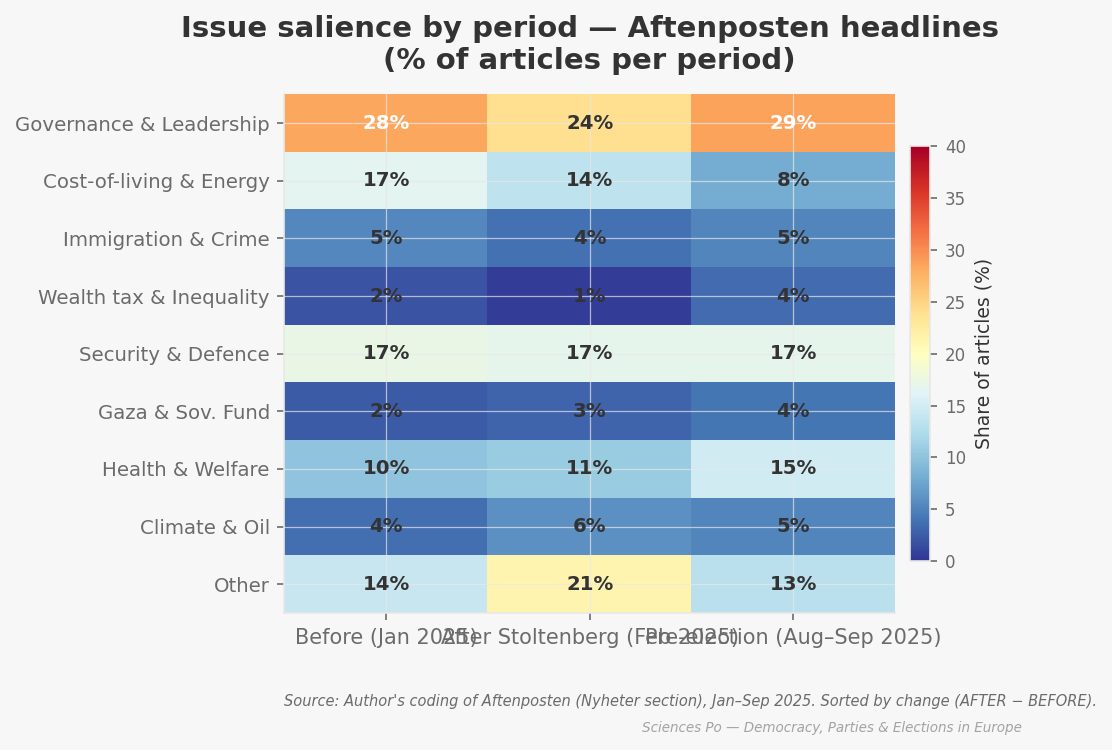

In [130]:
hm = code_pct.copy()
hm["change"] = hm.get("AFTER", 0) - hm.get("BEFORE", 0)
hm = hm.sort_values("change", ascending=True).drop(columns="change")

fig, ax = plt.subplots(figsize=(7, 5))
mat = hm.fillna(0).values
im = ax.imshow(
    mat, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=max(np.nanmax(mat), 40)
)

ax.set_xticks(range(len(PERIOD_ORDER)))
ax.set_xticklabels(
    [PERIOD_LABELS[p].replace("\n", " ") for p in PERIOD_ORDER], fontsize=10
)
ax.set_yticks(range(len(hm.index)))
ax.set_yticklabels(
    [ISSUE_LABELS.get(c, c).replace("\n", " ") for c in hm.index], fontsize=9.5
)

for i in range(len(hm.index)):
    for j, p in enumerate(PERIOD_ORDER):
        v = mat[i, j]
        if not period_has_data[p]:
            ax.text(
                j, i, "—", ha="center", va="center", fontsize=9.5, color=SCPO_MIDGREY
            )
        else:
            ax.text(
                j,
                i,
                f"{v:.0f}%",
                ha="center",
                va="center",
                fontsize=9.5,
                fontweight="bold",
                color="white" if v > 25 else SCPO_DARKGREY,
            )

ax.set_title(
    "Issue salience by period — Aftenposten headlines\n(% of articles per period)",
    pad=12,
)
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Share of articles (%)", fontsize=9)
cbar.ax.tick_params(labelsize=8)
add_source(ax, "Sorted by change (AFTER − BEFORE).")
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig2_issue_heatmap.png")
fig.savefig(OUTPUT_DIR / "fig2_issue_heatmap.pdf")
plt.show()


## Figure 3 — Leader Visibility


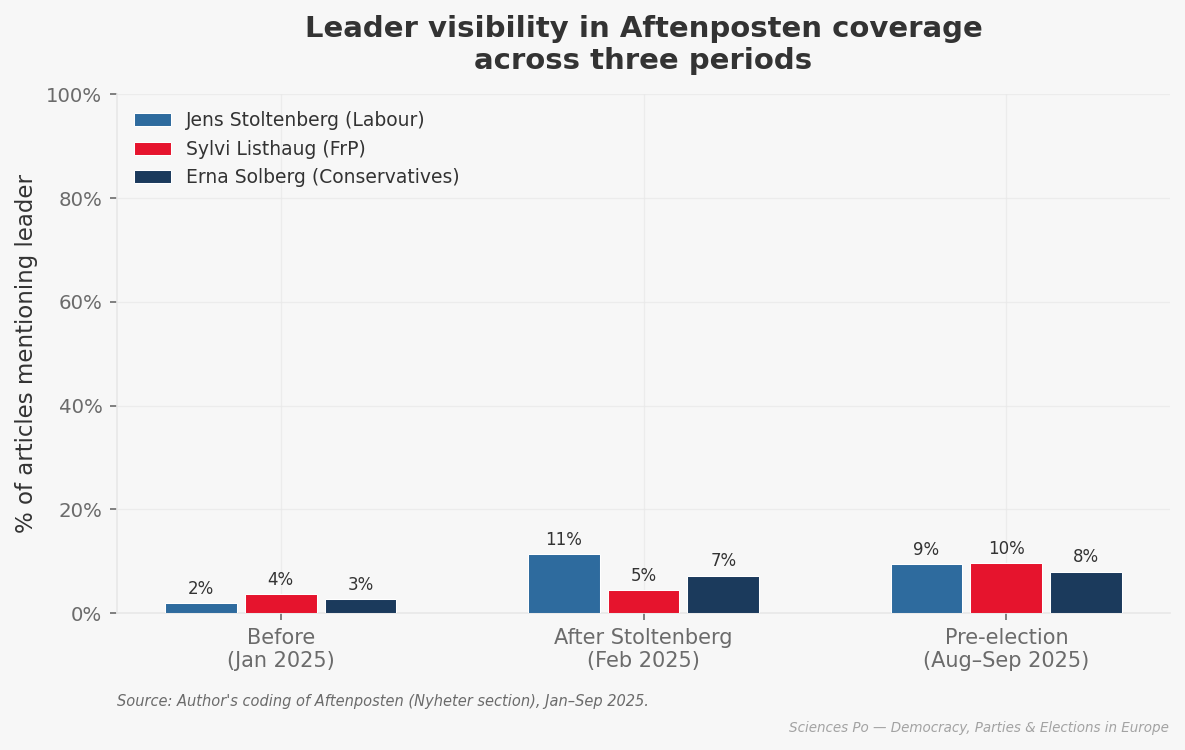

In [131]:
leaders = {
    "stoltenberg": ("Jens Stoltenberg (Labour)", PAL["blue"]),
    "listhaug": ("Sylvi Listhaug (FrP)", SCPO_RED),
    "solberg": ("Erna Solberg (Conservatives)", PAL["blue_dark"]),
}

leader_pct = {}
for period in PERIOD_ORDER:
    sub = dfa[dfa["period"] == period]
    n = len(sub)
    for ldr in leaders:
        col = f"flag_{ldr}"
        if col in sub.columns and n > 0:
            leader_pct.setdefault(ldr, {})[period] = sub[col].sum() / n * 100

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(PERIOD_ORDER))
width = 0.22

for i, (ldr, (label, color)) in enumerate(leaders.items()):
    vals = [leader_pct.get(ldr, {}).get(p, 0) for p in PERIOD_ORDER]
    bars = ax.bar(
        x + (i - 1) * width,
        vals,
        width * 0.9,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{v:.0f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                color=SCPO_DARKGREY,
                fontweight="medium",
            )

ax.set_xticks(x)
ax.set_xticklabels([PERIOD_LABELS[p] for p in PERIOD_ORDER], fontsize=10)
ax.set_ylabel("% of articles mentioning leader")
ax.set_title("Leader visibility in Aftenposten coverage\nacross three periods", pad=12)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="upper left")
add_source(ax)
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig3_leader_mentions.png")
fig.savefig(OUTPUT_DIR / "fig3_leader_mentions.pdf")
plt.show()


## Figure 4 — Tone toward Labour (stacked bars)


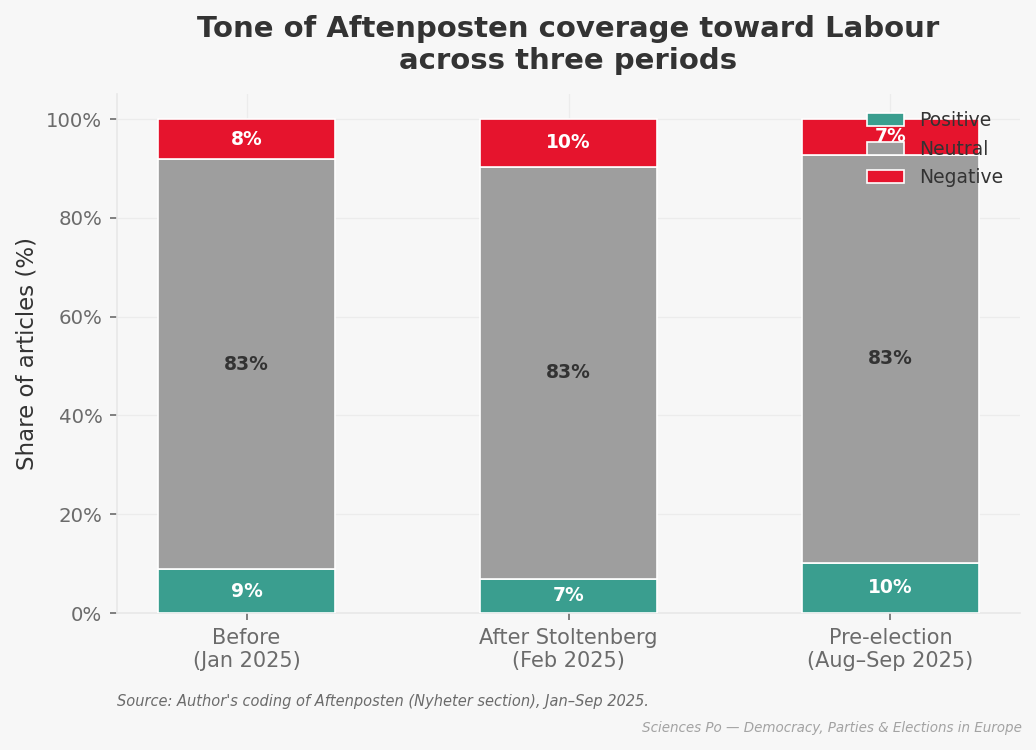

In [132]:
tone_order = ["POS", "NEU", "NEG"]
tone_cfg = {
    "POS": ("Positive", PAL["teal"]),
    "NEU": ("Neutral", PAL["grey"]),
    "NEG": ("Negative", SCPO_RED),
}

tone_pct = (
    pd.crosstab(dfa["tone_ap"], dfa["period"], normalize="columns")
    .reindex(index=tone_order, columns=PERIOD_ORDER)
    .fillna(0)
    * 100
)

fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(PERIOD_ORDER))

for tone in tone_order:
    vals = np.array(
        [tone_pct.loc[tone, p] if tone in tone_pct.index else 0 for p in PERIOD_ORDER]
    )
    label, color = tone_cfg[tone]
    ax.bar(
        range(len(PERIOD_ORDER)),
        vals,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        width=0.55,
        zorder=3,
    )
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(
                j,
                b + v / 2,
                f"{v:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white" if tone != "NEU" else SCPO_DARKGREY,
            )
    bottom += vals

ax.set_xticks(range(len(PERIOD_ORDER)))
ax.set_xticklabels([PERIOD_LABELS[p] for p in PERIOD_ORDER], fontsize=10)
ax.set_ylabel("Share of articles (%)")
ax.set_title("Tone of Aftenposten coverage toward Labour\nacross three periods", pad=12)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="upper right")
add_source(ax)
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig4_tone_labour.png")
fig.savefig(OUTPUT_DIR / "fig4_tone_labour.pdf")
plt.show()


## Figure 5 — The Repriming Slope Chart (paper-ready hero figure)


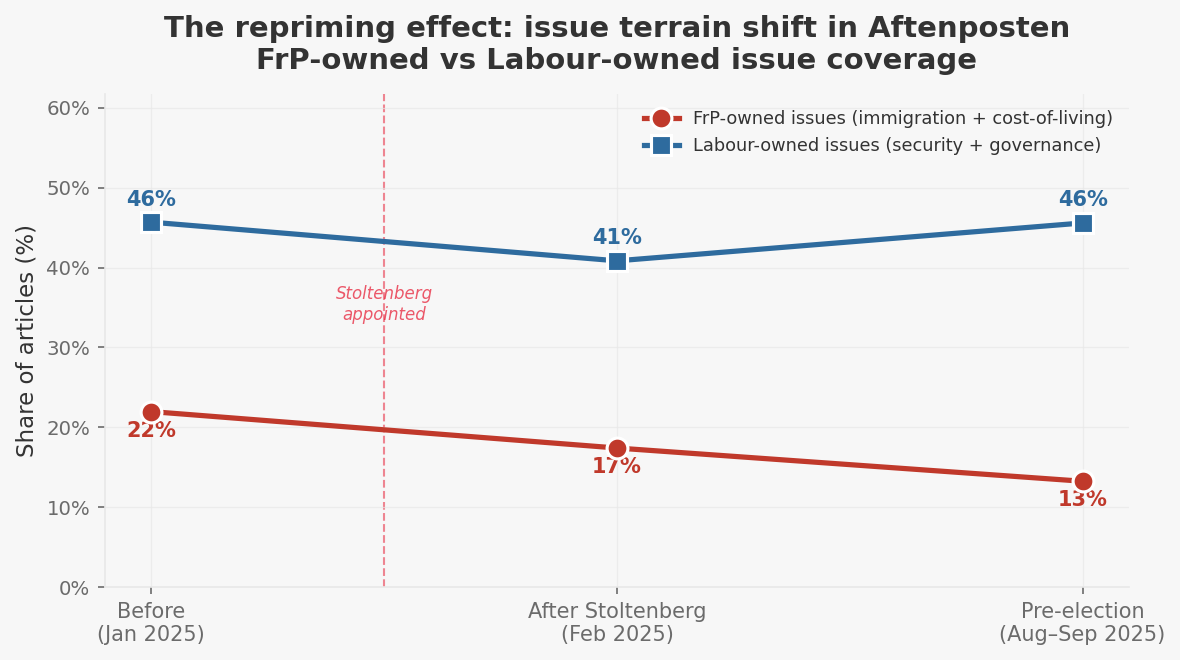

In [ ]:
frp_vals = [
    group_pct.loc["FrP-owned", p] if "FrP-owned" in group_pct.index else 0
    for p in PERIOD_ORDER
]
lab_vals = [
    group_pct.loc["Labour-owned", p] if "Labour-owned" in group_pct.index else 0
    for p in PERIOD_ORDER
]
x = np.arange(len(PERIOD_ORDER))

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    x,
    frp_vals,
    "-o",
    color=GROUP_COLORS["FrP-owned"],
    linewidth=2.5,
    markersize=10,
    markeredgecolor="white",
    markeredgewidth=1.5,
    zorder=5,
    label="FrP-owned issues (immigration + cost-of-living)",
)
ax.plot(
    x,
    lab_vals,
    "-s",
    color=GROUP_COLORS["Labour-owned"],
    linewidth=2.5,
    markersize=10,
    markeredgecolor="white",
    markeredgewidth=1.5,
    zorder=5,
    label="Labour-owned issues (security + governance)",
)

for i, (fv, lv) in enumerate(zip(frp_vals, lab_vals)):
    off_f = 8 if fv >= lv else -12
    off_l = 8 if lv > fv else -12
    # Avoid overlap when values are close
    if abs(fv - lv) < 5:
        off_f, off_l = 10, -14
    ax.annotate(
        f"{fv:.0f}%",
        (x[i], fv),
        textcoords="offset points",
        xytext=(0, off_f),
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=GROUP_COLORS["FrP-owned"],
    )
    ax.annotate(
        f"{lv:.0f}%",
        (x[i], lv),
        textcoords="offset points",
        xytext=(0, off_l),
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=GROUP_COLORS["Labour-owned"],
    )

# Treatment marker
ax.axvline(x=0.5, color=SCPO_RED, linewidth=1, linestyle="--", alpha=0.5, zorder=1)
ax.text(
    0.5,
    ax.get_ylim()[1] * 0.8 if ax.get_ylim()[1] > 0 else 50,
    "Stoltenberg\nappointed",
    ha="center",
    va="top",
    fontsize=8,
    color=SCPO_RED,
    style="italic",
    alpha=0.7,
)

ax.set_xticks(x)
ax.set_xticklabels([PERIOD_LABELS[p] for p in PERIOD_ORDER], fontsize=10)
ax.set_ylabel("Share of articles (%)")
ax.set_title(
    "The repriming effect: issue terrain shift in Aftenposten\n"
    "FrP-owned vs Labour-owned issue coverage",
    pad=12,
)
ax.set_ylim(0, max(max(frp_vals), max(lab_vals)) * 1.35)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="upper right", fontsize=8.5, framealpha=0.9)
# add_source(ax)
# add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig5_repriming_slope.png")
fig.savefig(OUTPUT_DIR / "fig5_repriming_slope.pdf")
plt.show()


## Figure 6 — Daily Issue Terrain (rolling average)

Day-by-day share of FrP-owned vs Labour-owned articles, with a 3-day rolling window to smooth daily noise.


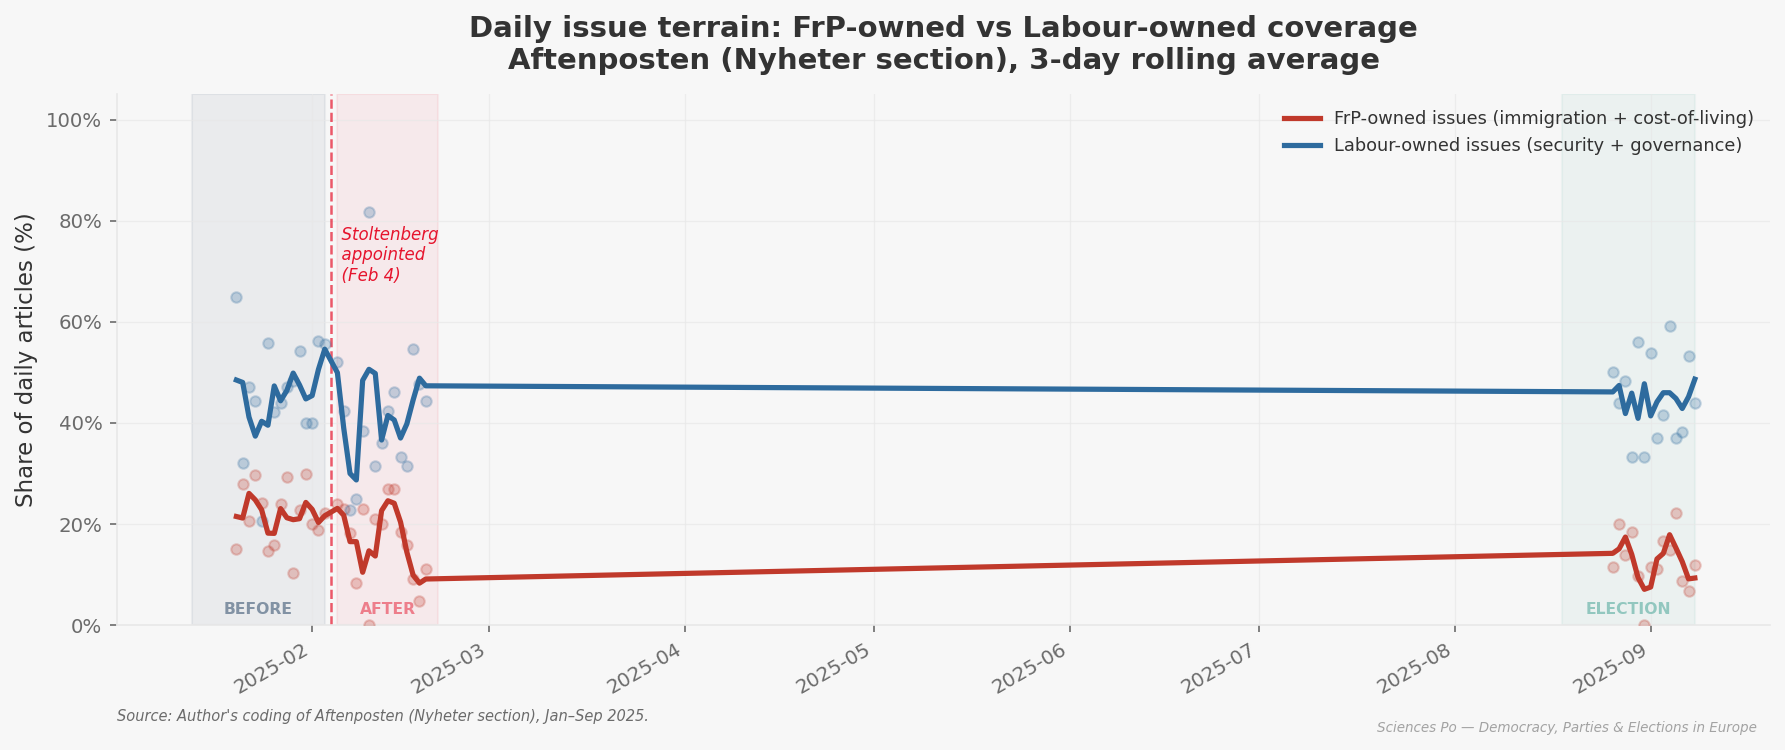

In [134]:
# Constants needed for daily charts
ISSUE_COLORS = {
    "IMM": "#C0392B",
    "ECON": "#E67E22",
    "SEC": "#2E6B9E",
    "GOV": "#1B3A5C",
    "TAX": "#27AE60",
    "GAZ": "#8E44AD",
    "CLI": "#16A085",
    "HEA": "#D4707A",
    "OTH": "#BDC3C7",
}
WINDOW = 3  # rolling average window (days)

# Compute daily counts by issue group
daily = dfa.groupby(["date", "issue_group"]).size().unstack(fill_value=0)
daily_total = daily.sum(axis=1)

# Compute daily shares (%)
daily_pct = daily.div(daily_total, axis=0) * 100

# Ensure columns exist
for col in ["FrP-owned", "Labour-owned"]:
    if col not in daily_pct.columns:
        daily_pct[col] = 0.0

# Sort by date
daily_pct = daily_pct.sort_index()

# Rolling average (3-day window, centered)
WINDOW = 3
frp_roll = daily_pct["FrP-owned"].rolling(WINDOW, min_periods=1, center=True).mean()
lab_roll = daily_pct["Labour-owned"].rolling(WINDOW, min_periods=1, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))

# Raw daily dots
ax.scatter(
    daily_pct.index,
    daily_pct["FrP-owned"],
    color=GROUP_COLORS["FrP-owned"],
    alpha=0.25,
    s=25,
    zorder=3,
    label="_nolegend_",
)
ax.scatter(
    daily_pct.index,
    daily_pct["Labour-owned"],
    color=GROUP_COLORS["Labour-owned"],
    alpha=0.25,
    s=25,
    zorder=3,
    label="_nolegend_",
)

# Rolling lines
ax.plot(
    frp_roll.index,
    frp_roll.values,
    color=GROUP_COLORS["FrP-owned"],
    linewidth=2.5,
    zorder=4,
    label="FrP-owned issues (immigration + cost-of-living)",
)
ax.plot(
    lab_roll.index,
    lab_roll.values,
    color=GROUP_COLORS["Labour-owned"],
    linewidth=2.5,
    zorder=4,
    label="Labour-owned issues (security + governance)",
)

# Treatment line
ax.axvline(
    TREATMENT_DATE, color=SCPO_RED, linewidth=1.2, linestyle="--", alpha=0.7, zorder=2
)
ax.text(
    TREATMENT_DATE,
    ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 10 else 80,
    "  Stoltenberg\n  appointed\n  (Feb 4)",
    fontsize=8,
    color=SCPO_RED,
    style="italic",
    va="top",
)

# Period shading
for start, end, label, color in [
    (BEFORE_START, BEFORE_END, "BEFORE", PAL["blue_dark"]),
    (AFTER_START, AFTER_END, "AFTER", SCPO_RED),
    (ELECT_START, ELECT_END, "ELECTION", PAL["teal"]),
]:
    ax.axvspan(start, end, alpha=0.06, color=color, zorder=0)
    mid = start + (end - start) / 2
    ax.text(
        mid,
        ax.get_ylim()[1] * 0.02 if ax.get_ylim()[1] > 10 else 2,
        label,
        ha="center",
        va="bottom",
        fontsize=7.5,
        color=color,
        fontweight="bold",
        alpha=0.5,
    )

ax.set_ylabel("Share of daily articles (%)")
ax.set_title(
    "Daily issue terrain: FrP-owned vs Labour-owned coverage\n"
    f"Aftenposten (Nyheter section), {WINDOW}-day rolling average",
    pad=12,
)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=8.5)
fig.autofmt_xdate(rotation=30)
add_source(ax)
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig6_daily_issue_terrain.png")
fig.savefig(OUTPUT_DIR / "fig6_daily_issue_terrain.pdf")
plt.show()

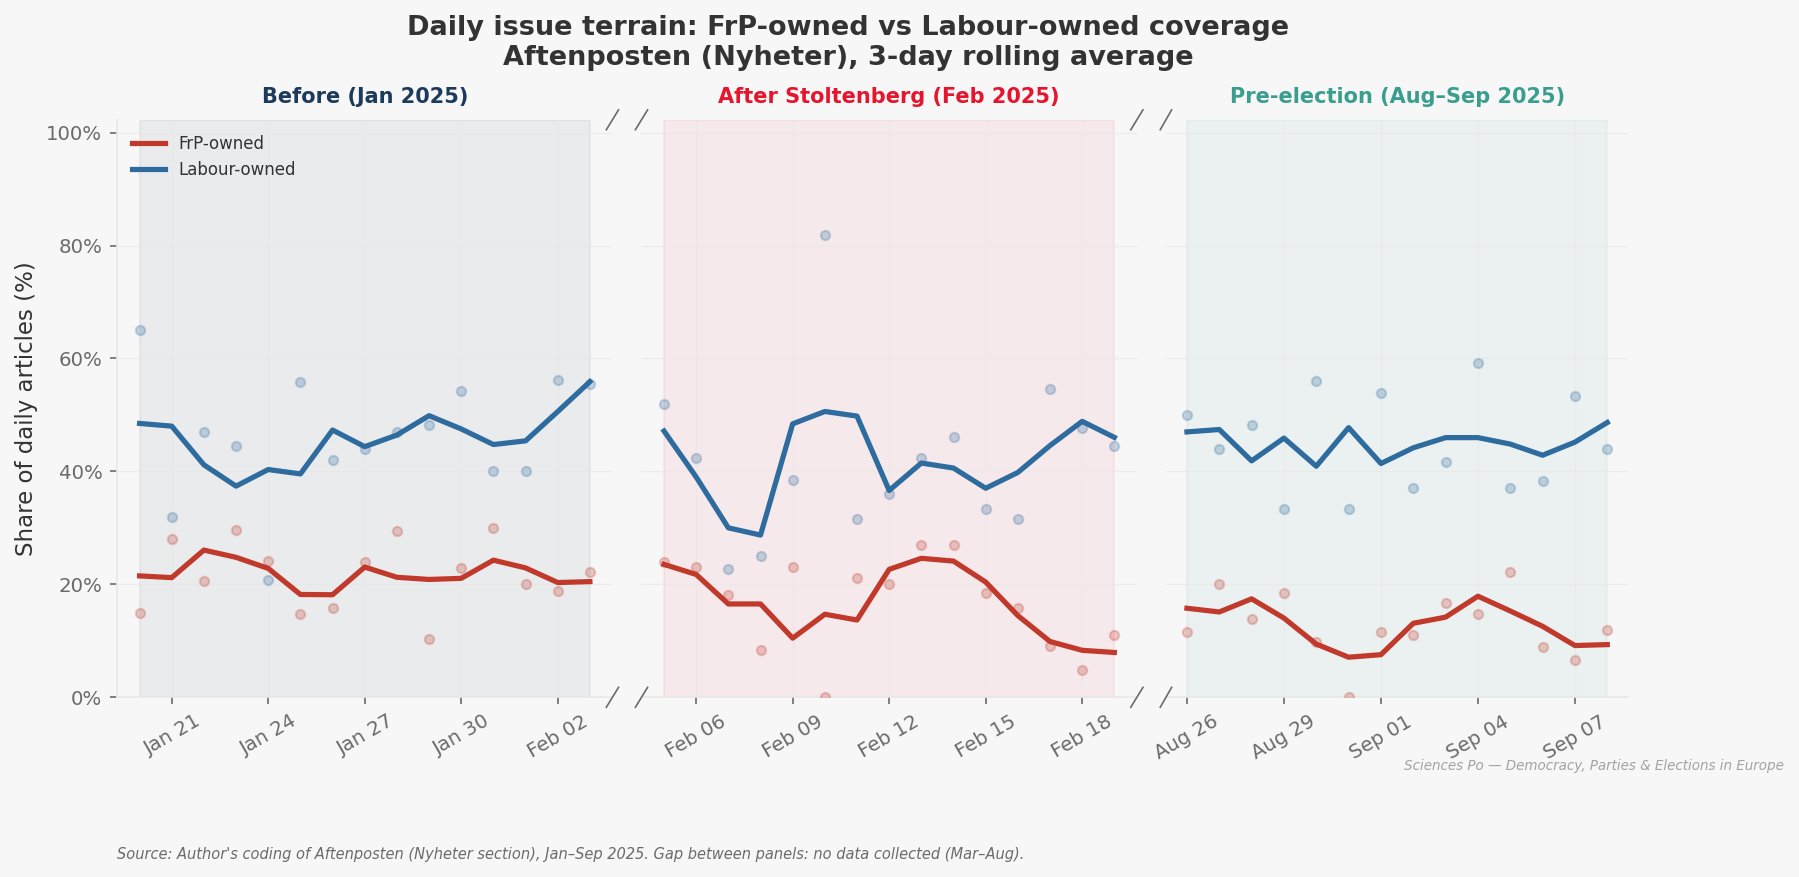

In [135]:
ISSUE_COLORS = {
    "IMM": "#C0392B",
    "ECON": "#E67E22",
    "SEC": "#2E6B9E",
    "GOV": "#1B3A5C",
    "TAX": "#27AE60",
    "GAZ": "#8E44AD",
    "CLI": "#16A085",
    "HEA": "#D4707A",
    "OTH": "#BDC3C7",
}
WINDOW = 3


# --- Helper: draw diagonal break marks between two axes ---
def draw_break_marks(ax_left, ax_right, fig, d=0.015, angle=35):
    """Draw diagonal break lines on the right edge of ax_left
    and left edge of ax_right."""
    import matplotlib.transforms as mtransforms

    for ax, side in [(ax_left, "right"), (ax_right, "left")]:
        x = 1.0 if side == "right" else 0.0
        kwargs = dict(
            transform=ax.transAxes,
            color=SCPO_MIDGREY,
            linewidth=0.8,
            clip_on=False,
            zorder=10,
        )
        dx = d * np.cos(np.radians(angle))
        dy = d * np.sin(np.radians(angle)) * 2
        # Top break
        ax.plot([x - dx, x + dx], [1 - dy, 1 + dy], **kwargs)
        # Bottom break
        ax.plot([x - dx, x + dx], [0 - dy, 0 + dy], **kwargs)


# --- Build per-period daily data ---
periods_data = {}
for period in PERIOD_ORDER:
    sub = dfa[dfa["period"] == period]
    if sub.empty:
        continue
    daily = sub.groupby(["date", "issue_group"]).size().unstack(fill_value=0)
    daily_total = daily.sum(axis=1)
    daily_pct = daily.div(daily_total, axis=0).fillna(0) * 100
    for col in ["FrP-owned", "Labour-owned"]:
        if col not in daily_pct.columns:
            daily_pct[col] = 0.0
    daily_pct = daily_pct.sort_index()
    periods_data[period] = daily_pct

active_periods = [p for p in PERIOD_ORDER if p in periods_data]
if len(active_periods) == 0:
    print("⚠ No data in any period — skipping daily charts.")
else:
    # Width ratios proportional to number of days in each period
    widths = []
    for p in active_periods:
        d = periods_data[p]
        span = (d.index.max() - d.index.min()).days + 1
        widths.append(max(span, 3))

    fig, axes = plt.subplots(
        1,
        len(active_periods),
        sharey=True,
        figsize=(13, 5),
        gridspec_kw={"width_ratios": widths, "wspace": 0.06},
    )
    if len(active_periods) == 1:
        axes = [axes]

    y_max = 0
    for idx, period in enumerate(active_periods):
        ax = axes[idx]
        dp = periods_data[period]

        frp_raw = dp["FrP-owned"]
        lab_raw = dp["Labour-owned"]
        frp_roll = frp_raw.rolling(WINDOW, min_periods=1, center=True).mean()
        lab_roll = lab_raw.rolling(WINDOW, min_periods=1, center=True).mean()

        # Dots (raw)
        ax.scatter(
            frp_raw.index,
            frp_raw.values,
            color=GROUP_COLORS["FrP-owned"],
            alpha=0.25,
            s=20,
            zorder=3,
        )
        ax.scatter(
            lab_raw.index,
            lab_raw.values,
            color=GROUP_COLORS["Labour-owned"],
            alpha=0.25,
            s=20,
            zorder=3,
        )

        # Rolling lines
        ax.plot(
            frp_roll.index,
            frp_roll.values,
            color=GROUP_COLORS["FrP-owned"],
            linewidth=2.5,
            zorder=4,
            label="FrP-owned" if idx == 0 else "_nolegend_",
        )
        ax.plot(
            lab_roll.index,
            lab_roll.values,
            color=GROUP_COLORS["Labour-owned"],
            linewidth=2.5,
            zorder=4,
            label="Labour-owned" if idx == 0 else "_nolegend_",
        )

        # Period background tint
        ax.axvspan(
            dp.index.min(),
            dp.index.max(),
            alpha=0.06,
            color=PERIOD_COLORS[period],
            zorder=0,
        )

        # Treatment line (only if in this panel's date range)
        if dp.index.min() <= TREATMENT_DATE <= dp.index.max():
            ax.axvline(
                TREATMENT_DATE,
                color=SCPO_RED,
                linewidth=1.2,
                linestyle="--",
                alpha=0.7,
                zorder=2,
            )
            ax.text(
                TREATMENT_DATE,
                97,
                "  Feb 4",
                fontsize=7.5,
                color=SCPO_RED,
                style="italic",
                va="top",
            )

        # Period label at top
        ax.set_title(
            PERIOD_LABELS[period].replace("\n", " "),
            fontsize=10,
            fontweight="bold",
            color=PERIOD_COLORS[period],
            pad=8,
        )

        # X-axis formatting
        ax.tick_params(axis="x", rotation=30)
        import matplotlib.dates as mdates

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        if len(dp) > 10:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        else:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

        y_max = max(y_max, frp_raw.max(), lab_raw.max())

        # Hide inner spines
        if idx > 0:
            ax.spines["left"].set_visible(False)
            ax.tick_params(left=False)
        if idx < len(active_periods) - 1:
            ax.spines["right"].set_visible(False)

    # Draw break marks between panels
    for i in range(len(active_periods) - 1):
        draw_break_marks(axes[i], axes[i + 1], fig)

    # Shared y-axis
    axes[0].set_ylim(0, min(y_max * 1.25, 105))
    axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    axes[0].set_ylabel("Share of daily articles (%)")

    # Legend on first panel
    axes[0].legend(loc="upper left", fontsize=8, framealpha=0.9)

    fig.suptitle(
        "Daily issue terrain: FrP-owned vs Labour-owned coverage\n"
        f"Aftenposten (Nyheter), {WINDOW}-day rolling average",
        fontsize=13,
        fontweight="bold",
        color=SCPO_DARKGREY,
        y=1.02,
    )
    add_watermark(fig)
    # Source note under leftmost panel
    axes[0].annotate(
        "Source: Author's coding of Aftenposten (Nyheter section), Jan–Sep 2025. "
        "Gap between panels: no data collected (Mar–Aug).",
        xy=(0, -0.28),
        xycoords="axes fraction",
        fontsize=7,
        color=SCPO_MIDGREY,
        style="italic",
    )

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig6_daily_issue_terrain.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "fig6_daily_issue_terrain.pdf", bbox_inches="tight")
    plt.show()


## Figure 7 — Daily article count by issue code (stacked area)

Shows the full issue landscape day by day as a stacked area chart.


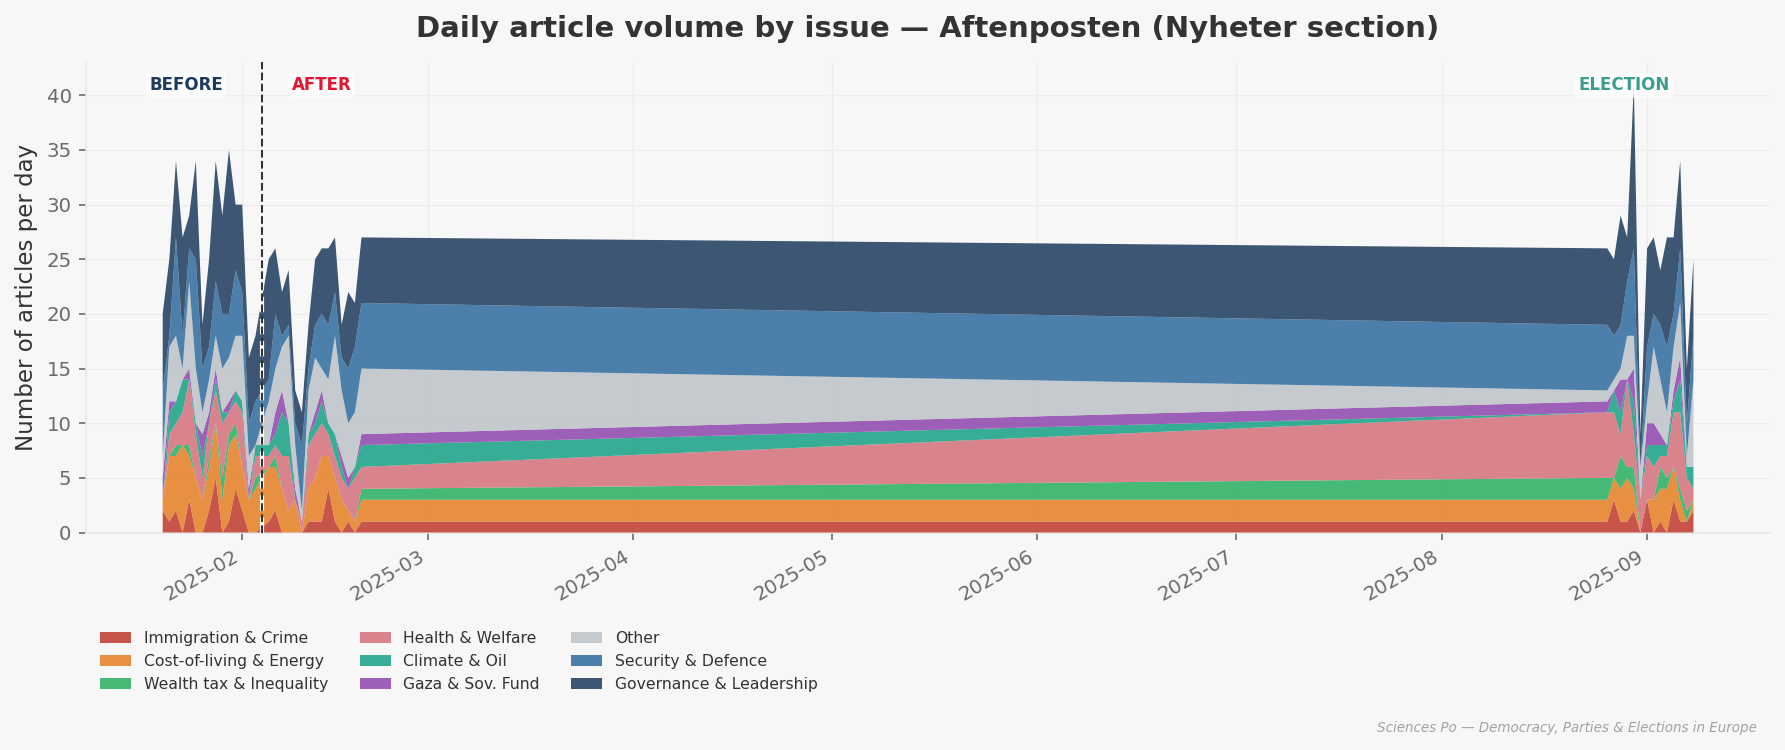

In [136]:
# Daily counts per issue code
daily_code = (
    dfa.groupby(["date", "issue_code"]).size().unstack(fill_value=0).sort_index()
)

# Reorder codes: FrP-owned at bottom, Labour-owned on top
code_order = ["IMM", "ECON", "TAX", "HEA", "CLI", "GAZ", "OTH", "SEC", "GOV"]
code_order = [c for c in code_order if c in daily_code.columns]

fig, ax = plt.subplots(figsize=(12, 5))

ax.stackplot(
    daily_code.index,
    *[daily_code[c].values for c in code_order],
    labels=[ISSUE_LABELS.get(c, c).replace("\n", " ") for c in code_order],
    colors=[ISSUE_COLORS.get(c, "#BDC3C7") for c in code_order],
    alpha=0.85,
    zorder=3,
)

# Treatment line
ax.axvline(TREATMENT_DATE, color="white", linewidth=2, linestyle="--", zorder=5)
ax.axvline(TREATMENT_DATE, color=SCPO_DARKGREY, linewidth=1, linestyle="--", zorder=5)

# Period shading labels
for start, end, label, color in [
    (BEFORE_START, BEFORE_END, "BEFORE", PAL["blue_dark"]),
    (AFTER_START, AFTER_END, "AFTER", SCPO_RED),
    (ELECT_START, ELECT_END, "ELECTION", PAL["teal"]),
]:
    mid = start + (end - start) / 2
    ax.text(
        mid,
        ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] > 5 else 5,
        label,
        ha="center",
        va="top",
        fontsize=8,
        color=color,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )

ax.set_ylabel("Number of articles per day")
ax.set_title("Daily article volume by issue — Aftenposten (Nyheter section)", pad=12)
ax.legend(
    loc="upper left", fontsize=7.5, ncol=3, bbox_to_anchor=(0, -0.18), frameon=False
)
fig.autofmt_xdate(rotation=30)
add_watermark(fig)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
fig.savefig(OUTPUT_DIR / "fig7_daily_stacked_area.png")
fig.savefig(OUTPUT_DIR / "fig7_daily_stacked_area.pdf")
plt.show()

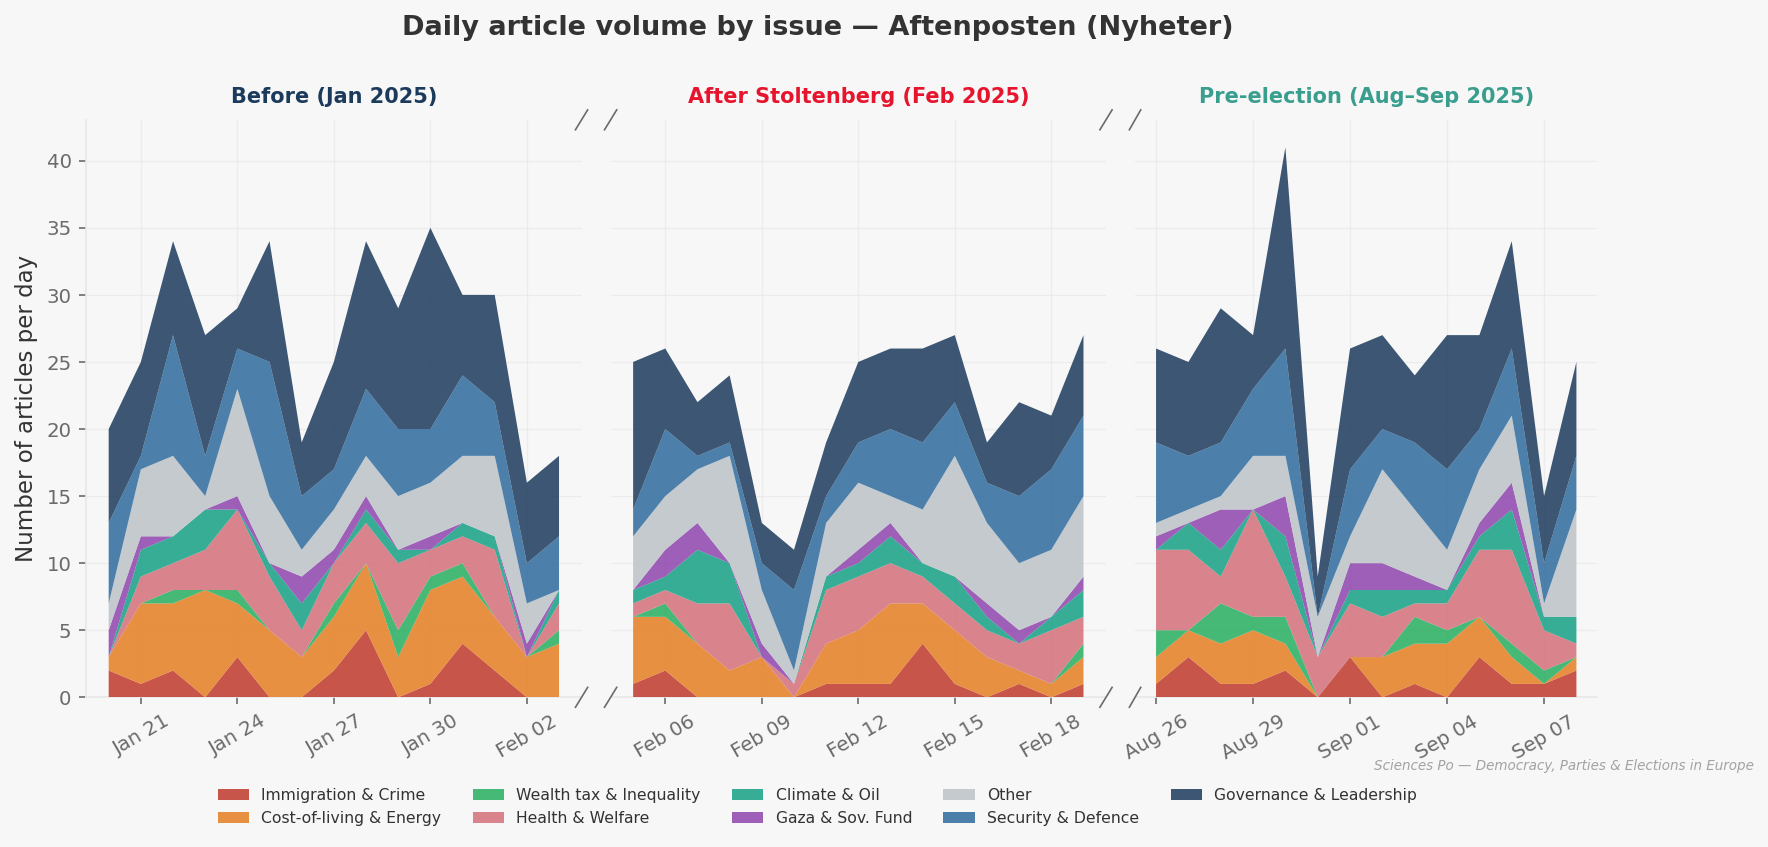

In [137]:
if len(active_periods) > 0:
    code_order = ["IMM", "ECON", "TAX", "HEA", "CLI", "GAZ", "OTH", "SEC", "GOV"]

    fig, axes = plt.subplots(
        1,
        len(active_periods),
        sharey=True,
        figsize=(13, 5),
        gridspec_kw={"width_ratios": widths, "wspace": 0.06},
    )
    if len(active_periods) == 1:
        axes = [axes]

    for idx, period in enumerate(active_periods):
        ax = axes[idx]
        sub = dfa[dfa["period"] == period]
        daily_code = (
            sub.groupby(["date", "issue_code"])
            .size()
            .unstack(fill_value=0)
            .sort_index()
        )
        codes_present = [c for c in code_order if c in daily_code.columns]

        ax.stackplot(
            daily_code.index,
            *[daily_code[c].values for c in codes_present],
            labels=[ISSUE_LABELS.get(c, c).replace("\n", " ") for c in codes_present]
            if idx == 0
            else ["_nolegend_"] * len(codes_present),
            colors=[ISSUE_COLORS.get(c, "#BDC3C7") for c in codes_present],
            alpha=0.85,
            zorder=3,
        )

        if (
            periods_data[period].index.min()
            <= TREATMENT_DATE
            <= periods_data[period].index.max()
        ):
            ax.axvline(
                TREATMENT_DATE, color="white", linewidth=2, linestyle="--", zorder=5
            )
            ax.axvline(
                TREATMENT_DATE,
                color=SCPO_DARKGREY,
                linewidth=1,
                linestyle="--",
                zorder=5,
            )

        ax.set_title(
            PERIOD_LABELS[period].replace("\n", " "),
            fontsize=10,
            fontweight="bold",
            color=PERIOD_COLORS[period],
            pad=8,
        )

        import matplotlib.dates as mdates

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.tick_params(axis="x", rotation=30)
        if len(daily_code) > 10:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        else:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

        if idx > 0:
            ax.spines["left"].set_visible(False)
            ax.tick_params(left=False)
        if idx < len(active_periods) - 1:
            ax.spines["right"].set_visible(False)

    for i in range(len(active_periods) - 1):
        draw_break_marks(axes[i], axes[i + 1], fig)

    axes[0].set_ylabel("Number of articles per day")

    fig.suptitle(
        "Daily article volume by issue — Aftenposten (Nyheter)",
        fontsize=13,
        fontweight="bold",
        color=SCPO_DARKGREY,
        y=1.02,
    )

    # Legend below
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        fontsize=7.5,
        ncol=5,
        bbox_to_anchor=(0.5, -0.08),
        frameon=False,
    )

    add_watermark(fig)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig7_daily_stacked_area.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "fig7_daily_stacked_area.pdf", bbox_inches="tight")
    plt.show()


## Figure 8 — Daily Stoltenberg mention rate

Tracks how often Stoltenberg appears in articles day by day, showing the "Stoltenberg saturation" of the news cycle.


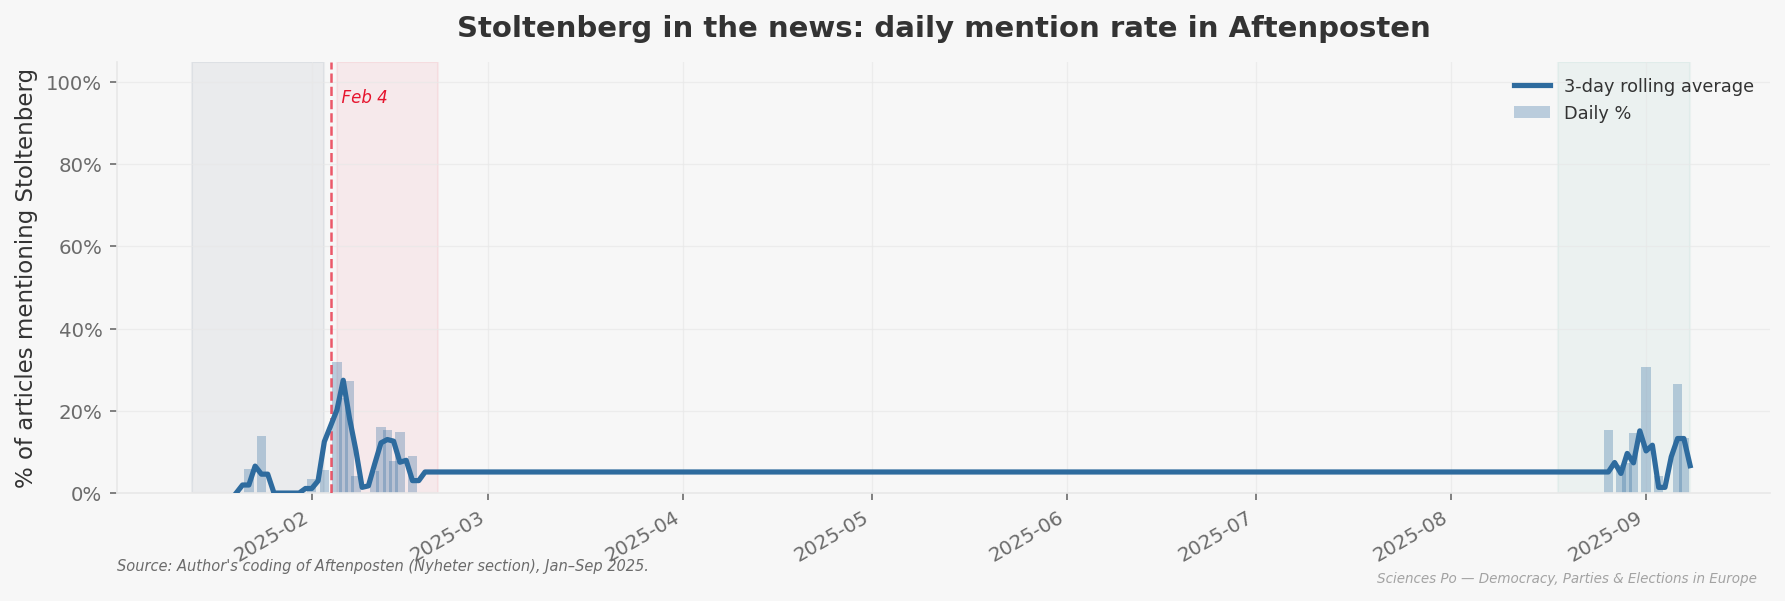

In [138]:
if "flag_stoltenberg" in dfa.columns:
    daily_stolt = dfa.groupby("date").agg(
        total=("flag_stoltenberg", "size"),
        stolt=("flag_stoltenberg", "sum"),
    )
    daily_stolt["pct"] = daily_stolt["stolt"] / daily_stolt["total"] * 100
    daily_stolt = daily_stolt.sort_index()
    stolt_roll = daily_stolt["pct"].rolling(WINDOW, min_periods=1, center=True).mean()

    fig, ax = plt.subplots(figsize=(12, 4))

    # Bar for raw daily %
    ax.bar(
        daily_stolt.index,
        daily_stolt["pct"],
        width=1.5,
        color=PAL["blue"],
        alpha=0.3,
        zorder=2,
        label="Daily %",
    )
    # Rolling line
    ax.plot(
        stolt_roll.index,
        stolt_roll.values,
        color=PAL["blue"],
        linewidth=2.5,
        zorder=4,
        label=f"{WINDOW}-day rolling average",
    )

    ax.axvline(
        TREATMENT_DATE,
        color=SCPO_RED,
        linewidth=1.2,
        linestyle="--",
        alpha=0.7,
        zorder=3,
    )
    ax.text(TREATMENT_DATE, 95, "  Feb 4", fontsize=8, color=SCPO_RED, style="italic")

    for start, end, color in [
        (BEFORE_START, BEFORE_END, PAL["blue_dark"]),
        (AFTER_START, AFTER_END, SCPO_RED),
        (ELECT_START, ELECT_END, PAL["teal"]),
    ]:
        ax.axvspan(start, end, alpha=0.06, color=color, zorder=0)

    ax.set_ylabel("% of articles mentioning Stoltenberg")
    ax.set_title("Stoltenberg in the news: daily mention rate in Aftenposten", pad=12)
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(loc="upper right", fontsize=8.5)
    fig.autofmt_xdate(rotation=30)
    add_source(ax)
    add_watermark(fig)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig8_daily_stoltenberg.png")
    fig.savefig(OUTPUT_DIR / "fig8_daily_stoltenberg.pdf")
    plt.show()
else:
    print("⚠ flag_stoltenberg column not found — skipping Figure 8.")


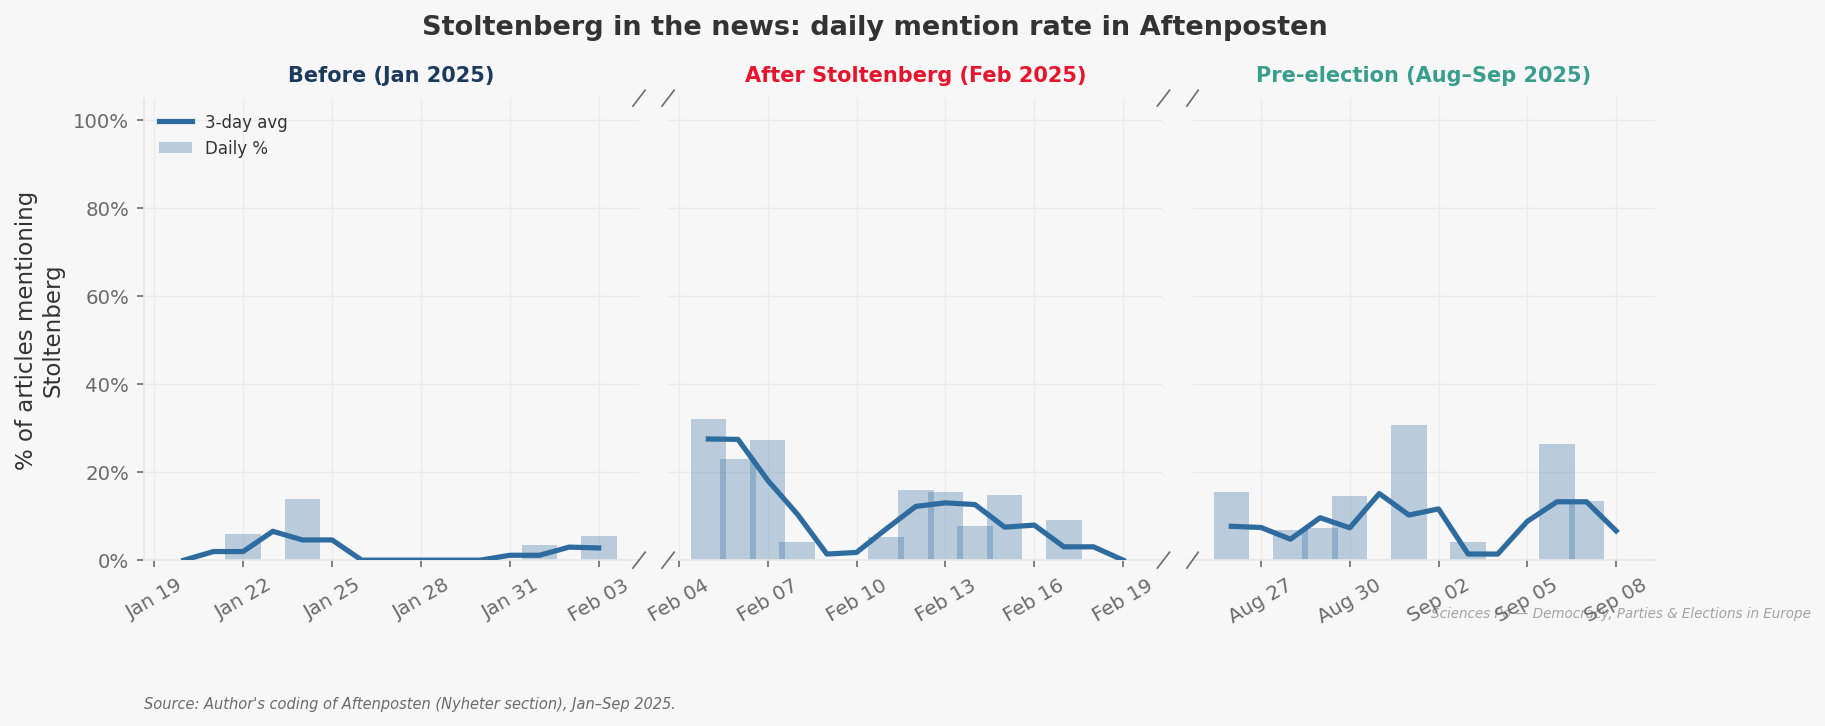

In [139]:
if "flag_stoltenberg" in dfa.columns and len(active_periods) > 0:
    fig, axes = plt.subplots(
        1,
        len(active_periods),
        sharey=True,
        figsize=(13, 4),
        gridspec_kw={"width_ratios": widths, "wspace": 0.06},
    )
    if len(active_periods) == 1:
        axes = [axes]

    for idx, period in enumerate(active_periods):
        ax = axes[idx]
        sub = dfa[dfa["period"] == period]
        daily_s = sub.groupby("date").agg(
            total=("flag_stoltenberg", "size"),
            stolt=("flag_stoltenberg", "sum"),
        )
        daily_s["pct"] = daily_s["stolt"] / daily_s["total"] * 100
        daily_s = daily_s.sort_index()
        roll = daily_s["pct"].rolling(WINDOW, min_periods=1, center=True).mean()

        ax.bar(
            daily_s.index,
            daily_s["pct"],
            width=1.2,
            color=PAL["blue"],
            alpha=0.3,
            zorder=2,
            label="Daily %" if idx == 0 else "_nolegend_",
        )
        ax.plot(
            roll.index,
            roll.values,
            color=PAL["blue"],
            linewidth=2.5,
            zorder=4,
            label=f"{WINDOW}-day avg" if idx == 0 else "_nolegend_",
        )

        if (
            periods_data[period].index.min()
            <= TREATMENT_DATE
            <= periods_data[period].index.max()
        ):
            ax.axvline(
                TREATMENT_DATE,
                color=SCPO_RED,
                linewidth=1.2,
                linestyle="--",
                alpha=0.7,
                zorder=3,
            )
            ax.text(
                TREATMENT_DATE,
                97,
                "  Feb 4",
                fontsize=7.5,
                color=SCPO_RED,
                style="italic",
                va="top",
            )

        ax.set_title(
            PERIOD_LABELS[period].replace("\n", " "),
            fontsize=10,
            fontweight="bold",
            color=PERIOD_COLORS[period],
            pad=8,
        )

        import matplotlib.dates as mdates

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.tick_params(axis="x", rotation=30)
        if len(daily_s) > 10:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        else:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

        if idx > 0:
            ax.spines["left"].set_visible(False)
            ax.tick_params(left=False)
        if idx < len(active_periods) - 1:
            ax.spines["right"].set_visible(False)

    for i in range(len(active_periods) - 1):
        draw_break_marks(axes[i], axes[i + 1], fig)

    axes[0].set_ylim(0, 105)
    axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    axes[0].set_ylabel("% of articles mentioning\nStoltenberg")
    axes[0].legend(loc="upper left", fontsize=8)

    fig.suptitle(
        "Stoltenberg in the news: daily mention rate in Aftenposten",
        fontsize=13,
        fontweight="bold",
        color=SCPO_DARKGREY,
        y=1.02,
    )
    axes[0].annotate(
        "Source: Author's coding of Aftenposten (Nyheter section), Jan–Sep 2025.",
        xy=(0, -0.32),
        xycoords="axes fraction",
        fontsize=7,
        color=SCPO_MIDGREY,
        style="italic",
    )
    add_watermark(fig)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig8_daily_stoltenberg.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "fig8_daily_stoltenberg.pdf", bbox_inches="tight")
    plt.show()


## Figure 9 — Daily Issue Group Evolution (all groups, toggleable)

Each issue group as a separate line, day by day with rolling average.
Toggle groups on/off by editing the SHOW_GROUPS dict below.


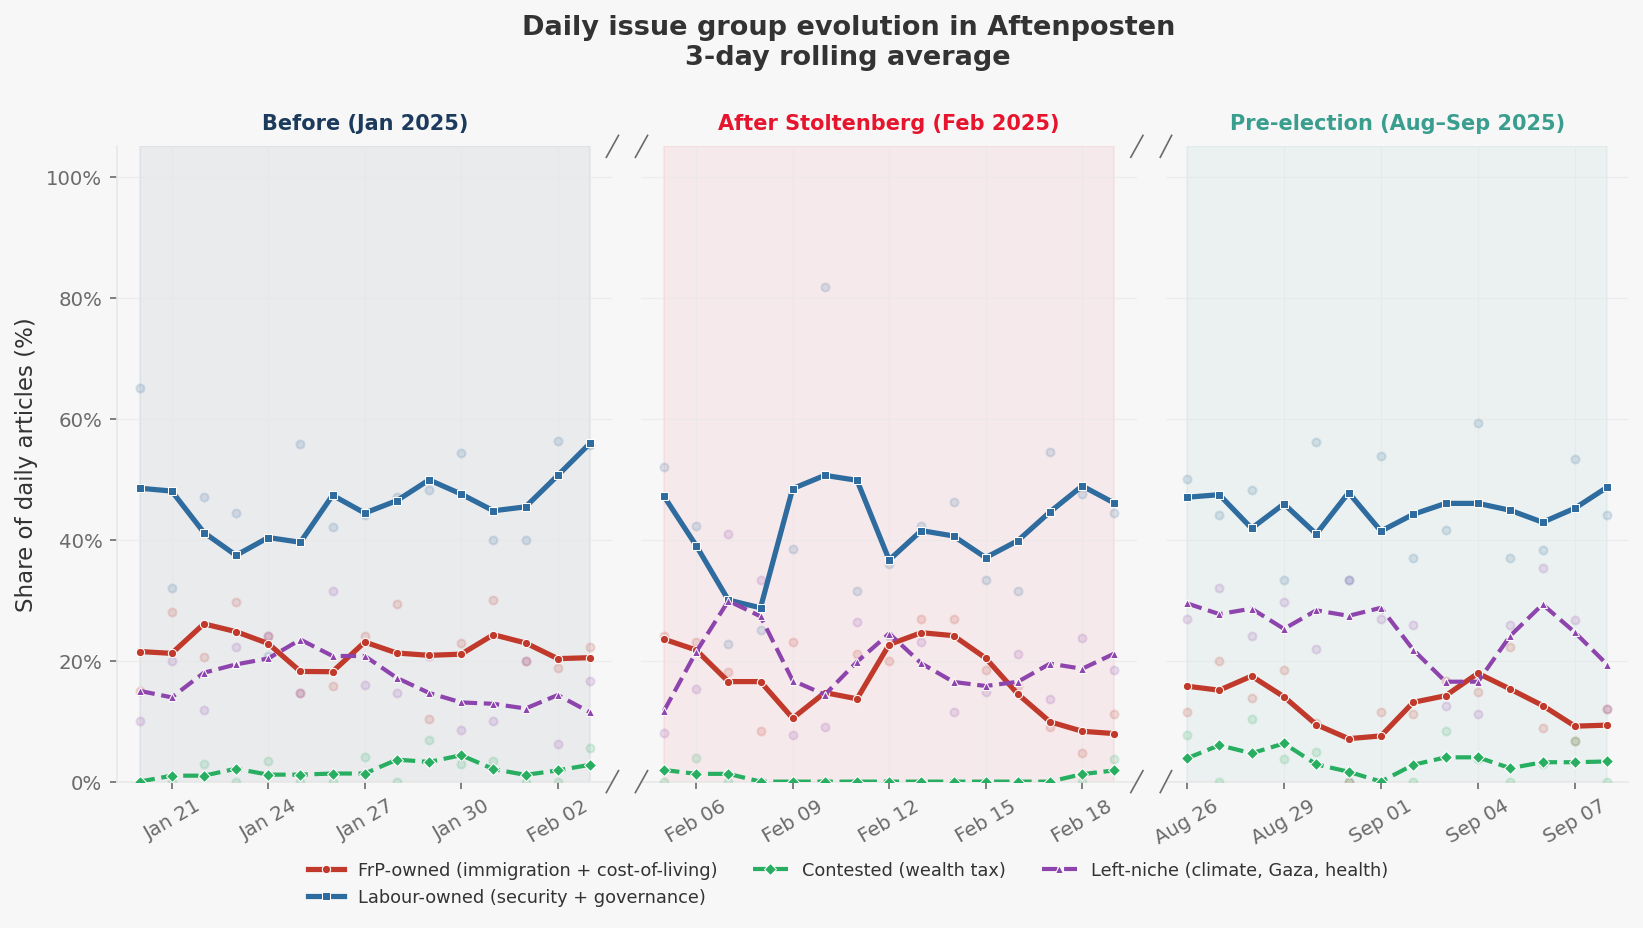

→ Saved fig9_daily_all_groups.png/pdf
  Groups shown: ['FrP-owned', 'Labour-owned', 'Contested', 'Left-niche']


In [149]:
# ======================================================
# TOGGLE GROUPS ON/OFF HERE — set to True/False
# ======================================================
SHOW_GROUPS = {
    "FrP-owned": True,  # Immigration + cost-of-living
    "Labour-owned": True,  # Security + governance
    "Contested": True,  # Wealth tax
    "Left-niche": True,  # Climate, Gaza, health
    "Other": False,  # Unclassifiable (usually noise)
}
# ======================================================

GROUP_STYLES = {
    "FrP-owned": {"color": "#C0392B", "marker": "o", "ls": "-", "lw": 2.5},
    "Labour-owned": {"color": "#2E6B9E", "marker": "s", "ls": "-", "lw": 2.5},
    "Contested": {"color": "#27AE60", "marker": "D", "ls": "--", "lw": 2.0},
    "Left-niche": {"color": "#8E44AD", "marker": "^", "ls": "--", "lw": 2.0},
    "Other": {"color": "#BDC3C7", "marker": "x", "ls": ":", "lw": 1.5},
}

GROUP_NICE_LABELS = {
    "FrP-owned": "FrP-owned (immigration + cost-of-living)",
    "Labour-owned": "Labour-owned (security + governance)",
    "Contested": "Contested (wealth tax)",
    "Left-niche": "Left-niche (climate, Gaza, health)",
    "Other": "Other",
}

visible_groups = [g for g, show in SHOW_GROUPS.items() if show]

# Build daily group percentages per period
periods_grp = {}
for period in PERIOD_ORDER:
    sub = dfa[dfa["period"] == period]
    if sub.empty:
        continue
    daily = sub.groupby(["date", "issue_group"]).size().unstack(fill_value=0)
    daily_total = daily.sum(axis=1)
    daily_pct = daily.div(daily_total, axis=0).fillna(0) * 100
    # Ensure all groups exist as columns
    for g in visible_groups:
        if g not in daily_pct.columns:
            daily_pct[g] = 0.0
    periods_grp[period] = daily_pct.sort_index()

active = [p for p in PERIOD_ORDER if p in periods_grp]

if not active:
    print("⚠ No data — skipping Figure 9.")
else:
    # Panel widths proportional to date span
    widths = []
    for p in active:
        d = periods_grp[p]
        span = (d.index.max() - d.index.min()).days + 1
        widths.append(max(span, 3))

    fig, axes = plt.subplots(
        1,
        len(active),
        sharey=True,
        figsize=(13, 5.5),
        gridspec_kw={"width_ratios": widths, "wspace": 0.06},
    )
    if len(active) == 1:
        axes = [axes]

    y_max = 0

    for idx, period in enumerate(active):
        ax = axes[idx]
        dp = periods_grp[period]

        for group in visible_groups:
            sty = GROUP_STYLES[group]
            raw = dp[group]
            roll = raw.rolling(WINDOW, min_periods=1, center=True).mean()

            # Faded dots for raw values
            ax.scatter(
                raw.index, raw.values, color=sty["color"], alpha=0.15, s=15, zorder=3
            )

            # Rolling average line
            ax.plot(
                roll.index,
                roll.values,
                color=sty["color"],
                linewidth=sty["lw"],
                linestyle=sty["ls"],
                marker=sty["marker"],
                markersize=4,
                markeredgecolor="white",
                markeredgewidth=0.5,
                zorder=4,
                label=GROUP_NICE_LABELS[group] if idx == 0 else "_nolegend_",
            )

            y_max = max(y_max, raw.max())

        # Period tint
        ax.axvspan(
            dp.index.min(),
            dp.index.max(),
            alpha=0.06,
            color=PERIOD_COLORS[period],
            zorder=0,
        )

        # Treatment line
        if dp.index.min() <= TREATMENT_DATE <= dp.index.max():
            ax.axvline(
                TREATMENT_DATE,
                color=SCPO_RED,
                linewidth=1.2,
                linestyle="--",
                alpha=0.7,
                zorder=2,
            )
            ax.text(
                TREATMENT_DATE,
                y_max * 1.1,
                "  Feb 4",
                fontsize=7.5,
                color=SCPO_RED,
                style="italic",
                va="top",
            )

        # Period title
        ax.set_title(
            PERIOD_LABELS[period].replace("\n", " "),
            fontsize=10,
            fontweight="bold",
            color=PERIOD_COLORS[period],
            pad=8,
        )

        # X-axis
        import matplotlib.dates as mdates

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.tick_params(axis="x", rotation=30)
        if len(dp) > 10:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        else:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

        # Hide inner spines
        if idx > 0:
            ax.spines["left"].set_visible(False)
            ax.tick_params(left=False)
        if idx < len(active) - 1:
            ax.spines["right"].set_visible(False)

    # Break marks
    for i in range(len(active) - 1):
        draw_break_marks(axes[i], axes[i + 1], fig)

    axes[0].set_ylim(0, min(y_max * 1.3, 105))
    axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    axes[0].set_ylabel("Share of daily articles (%)")

    # Legend below the chart
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.06),
        fontsize=8.5,
        ncol=min(len(visible_groups), 3),
        frameon=False,
    )

    title_extra = ""
    n_hidden = sum(1 for v in SHOW_GROUPS.values() if not v)

    fig.suptitle(
        f"Daily issue group evolution in Aftenposten\n"
        f"{WINDOW}-day rolling average{title_extra}",
        fontsize=13,
        fontweight="bold",
        color=SCPO_DARKGREY,
        y=1.04,
    )

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig9_daily_all_groups.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "fig9_daily_all_groups.pdf", bbox_inches="tight")
    plt.show()
    print("→ Saved fig9_daily_all_groups.png/pdf")
    print(f"  Groups shown: {visible_groups}")


## Figure 10 — Daily Issue Code Evolution (individual issues, toggleable)

Same logic as Figure 9 but at the granular issue-code level.
Toggle individual codes on/off below.


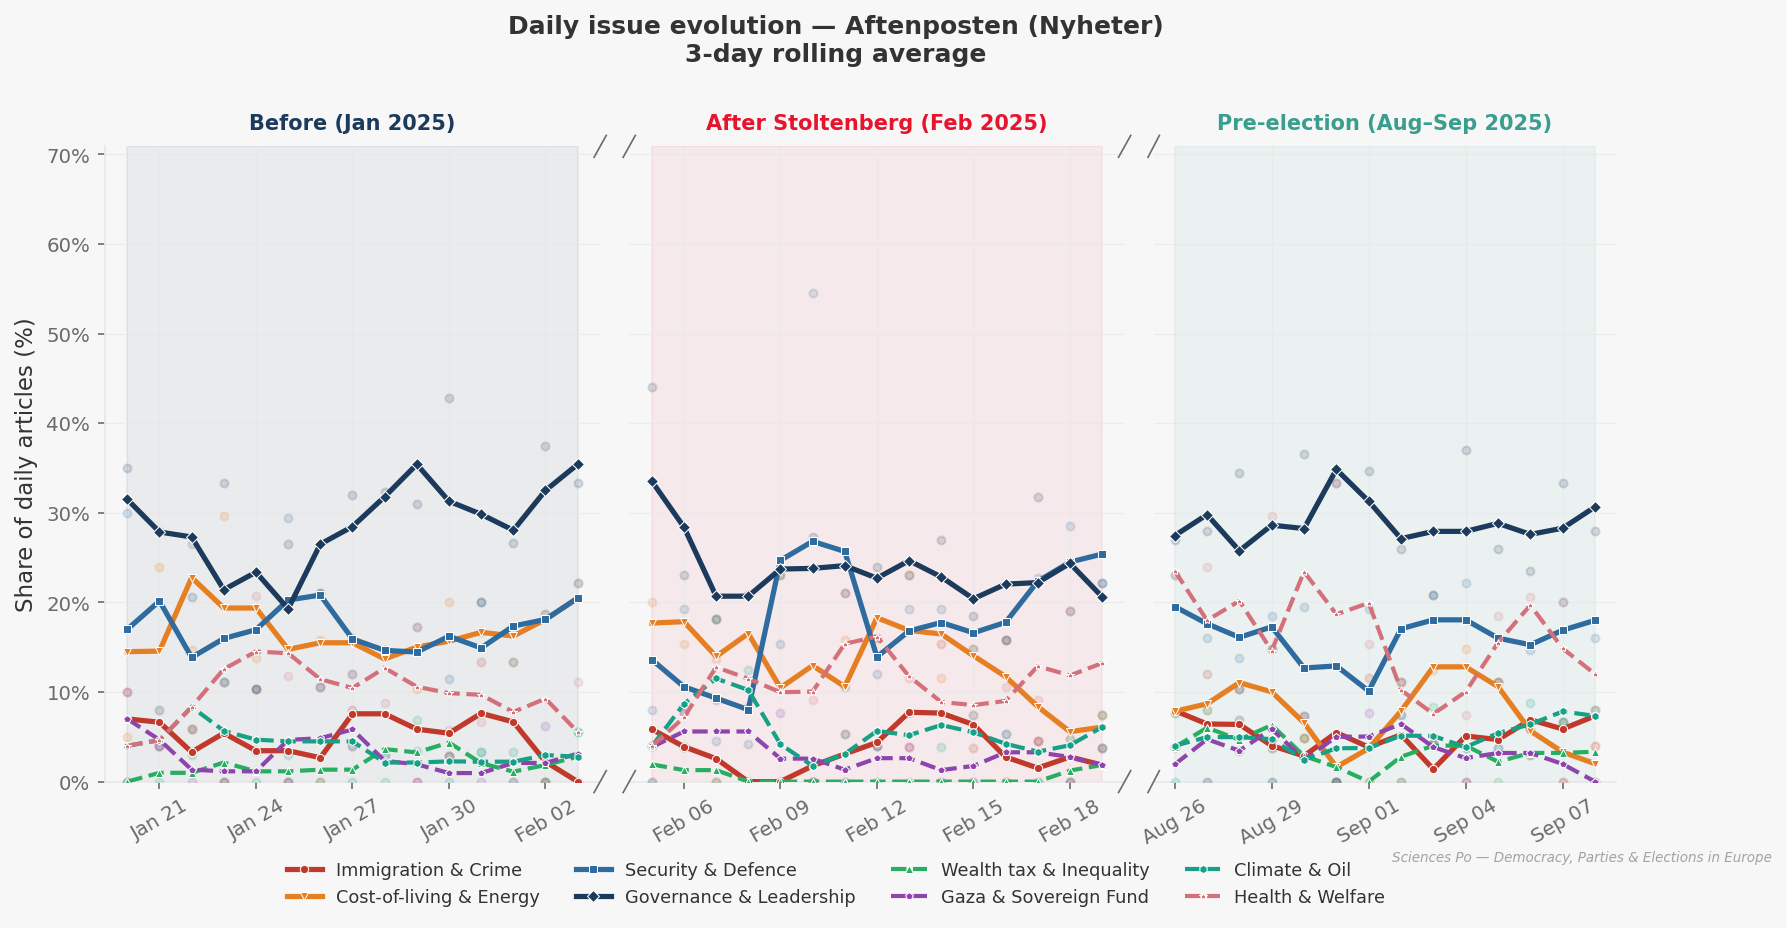

→ Saved fig10_daily_all_issues.png/pdf
  Issues shown: ['IMM', 'ECON', 'SEC', 'GOV', 'TAX', 'GAZ', 'CLI', 'HEA']


In [ ]:
# ======================================================
# TOGGLE ISSUES ON/OFF HERE — set to True/False
# ======================================================
SHOW_ISSUES = {
    "IMM": True,  # Immigration & Crime
    "ECON": True,  # Cost-of-living & Energy
    "SEC": True,  # Security & Defence
    "GOV": True,  # Governance & Leadership
    "TAX": True,  # Wealth tax & Inequality
    "GAZ": True,  # Gaza & Sovereign Fund
    "CLI": True,  # Climate & Oil
    "HEA": True,  # Health & Welfare
    "OTH": False,  # Other
}
# ======================================================

ISSUE_STYLES = {
    "IMM": {"color": "#C0392B", "marker": "o", "ls": "-", "lw": 2.5},
    "ECON": {"color": "#E67E22", "marker": "v", "ls": "-", "lw": 2.5},
    "SEC": {"color": "#2E6B9E", "marker": "s", "ls": "-", "lw": 2.5},
    "GOV": {"color": "#1B3A5C", "marker": "D", "ls": "-", "lw": 2.5},
    "TAX": {"color": "#27AE60", "marker": "^", "ls": "--", "lw": 2.0},
    "GAZ": {"color": "#8E44AD", "marker": "p", "ls": "--", "lw": 2.0},
    "CLI": {"color": "#16A085", "marker": "h", "ls": "--", "lw": 2.0},
    "HEA": {"color": "#D4707A", "marker": "*", "ls": "--", "lw": 2.0},
    "OTH": {"color": "#BDC3C7", "marker": "x", "ls": ":", "lw": 1.5},
}

ISSUE_NICE_LABELS = {
    "IMM": "Immigration & Crime",
    "ECON": "Cost-of-living & Energy",
    "SEC": "Security & Defence",
    "GOV": "Governance & Leadership",
    "TAX": "Wealth tax & Inequality",
    "GAZ": "Gaza & Sovereign Fund",
    "CLI": "Climate & Oil",
    "HEA": "Health & Welfare",
    "OTH": "Other",
}

visible_issues = [c for c, show in SHOW_ISSUES.items() if show]

# Build daily issue-code percentages per period
periods_issue = {}
for period in PERIOD_ORDER:
    sub = dfa[dfa["period"] == period]
    if sub.empty:
        continue
    daily = sub.groupby(["date", "issue_code"]).size().unstack(fill_value=0)
    daily_total = daily.sum(axis=1)
    daily_pct = daily.div(daily_total, axis=0).fillna(0) * 100
    for c in visible_issues:
        if c not in daily_pct.columns:
            daily_pct[c] = 0.0
    periods_issue[period] = daily_pct.sort_index()

active_i = [p for p in PERIOD_ORDER if p in periods_issue]

if not active_i:
    print("⚠ No data — skipping Figure 10.")
else:
    widths_i = []
    for p in active_i:
        d = periods_issue[p]
        span = (d.index.max() - d.index.min()).days + 1
        widths_i.append(max(span, 3))

    fig, axes = plt.subplots(
        1,
        len(active_i),
        sharey=True,
        figsize=(13, 5.5),
        gridspec_kw={"width_ratios": widths_i, "wspace": 0.06},
    )
    if len(active_i) == 1:
        axes = [axes]

    y_max = 0

    for idx, period in enumerate(active_i):
        ax = axes[idx]
        dp = periods_issue[period]

        for issue in visible_issues:
            sty = ISSUE_STYLES[issue]
            raw = dp[issue]
            roll = raw.rolling(WINDOW, min_periods=1, center=True).mean()

            ax.scatter(
                raw.index, raw.values, color=sty["color"], alpha=0.15, s=15, zorder=3
            )

            ax.plot(
                roll.index,
                roll.values,
                color=sty["color"],
                linewidth=sty["lw"],
                linestyle=sty["ls"],
                marker=sty["marker"],
                markersize=4,
                markeredgecolor="white",
                markeredgewidth=0.5,
                zorder=4,
                label=ISSUE_NICE_LABELS[issue] if idx == 0 else "_nolegend_",
            )

            y_max = max(y_max, raw.max())

        ax.axvspan(
            dp.index.min(),
            dp.index.max(),
            alpha=0.06,
            color=PERIOD_COLORS[period],
            zorder=0,
        )

        if dp.index.min() <= TREATMENT_DATE <= dp.index.max():
            ax.axvline(
                TREATMENT_DATE,
                color=SCPO_RED,
                linewidth=1.2,
                linestyle="--",
                alpha=0.7,
                zorder=2,
            )
            ax.text(
                TREATMENT_DATE,
                y_max * 1.1,
                "  Feb 4",
                fontsize=7.5,
                color=SCPO_RED,
                style="italic",
                va="top",
            )

        ax.set_title(
            PERIOD_LABELS[period].replace("\n", " "),
            fontsize=10,
            fontweight="bold",
            color=PERIOD_COLORS[period],
            pad=8,
        )

        import matplotlib.dates as mdates

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.tick_params(axis="x", rotation=30)
        if len(dp) > 10:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        else:
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

        if idx > 0:
            ax.spines["left"].set_visible(False)
            ax.tick_params(left=False)
        if idx < len(active_i) - 1:
            ax.spines["right"].set_visible(False)

    for i in range(len(active_i) - 1):
        draw_break_marks(axes[i], axes[i + 1], fig)

    axes[0].set_ylim(0, min(y_max * 1.3, 105))
    axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    axes[0].set_ylabel("Share of daily articles (%)")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.06),
        fontsize=8.5,
        ncol=min(len(visible_issues), 4),
        frameon=False,
    )

    n_hidden = sum(1 for v in SHOW_ISSUES.values() if not v)
    title_extra = ""

    fig.suptitle(
        f"Daily issue evolution in Aftenposten"
        f"\n{WINDOW}-day rolling average{title_extra}",
        fontsize=12,
        fontweight="bold",
        color=SCPO_DARKGREY,
        y=1.04,
    )

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig10_daily_all_issues.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "fig10_daily_all_issues.pdf", bbox_inches="tight")
    plt.show()
    print("→ Saved fig10_daily_all_issues.png/pdf")
    print(f"  Issues shown: {visible_issues}")


## Summary table for the paper


In [142]:
full_cross = (
    pd.crosstab(dfa["issue_code"], dfa["period"])
    .reindex(columns=PERIOD_ORDER)
    .fillna(0)
    .astype(int)
)
full_pct = (
    pd.crosstab(dfa["issue_code"], dfa["period"], normalize="columns")
    .reindex(columns=PERIOD_ORDER)
    .fillna(0)
    * 100
)

table = pd.DataFrame()
for p in PERIOD_ORDER:
    table[f"{p} (n)"] = full_cross[p]
    table[f"{p} (%)"] = full_pct[p].round(1)

table["Δ BEFORE→AFTER (pp)"] = (
    full_pct.get("AFTER", 0) - full_pct.get("BEFORE", 0)
).round(1)
table["Δ BEFORE→ELEC (pp)"] = (
    full_pct.get("ELECTION", 0) - full_pct.get("BEFORE", 0)
).round(1)
table = table.sort_values("Δ BEFORE→AFTER (pp)", ascending=False)

# Totals
totals = {f"{p} (n)": full_cross[p].sum() for p in PERIOD_ORDER}
totals.update({f"{p} (%)": 100.0 for p in PERIOD_ORDER})
totals["Δ BEFORE→AFTER (pp)"] = 0
totals["Δ BEFORE→ELEC (pp)"] = 0
table.loc["TOTAL"] = totals

print("=" * 75)
print("TABLE — Issue distribution by period (Aftenposten, Nyheter)")
print("=" * 75)
print(table.to_string())

# Issue groups
grp = group_pct.copy()
grp["Δ BEFORE→AFTER"] = (grp["AFTER"] - grp["BEFORE"]).round(1)
grp["Δ BEFORE→ELEC"] = (grp["ELECTION"] - grp["BEFORE"]).round(1)

print("\n" + "=" * 75)
print("ISSUE GROUPS — Hypothesis test")
print("=" * 75)
print(grp.round(1).to_string())
print("\n→ H1: Labour-owned should INCREASE after appointment")
print("→ H2: FrP-owned should DECREASE after appointment")

table.to_csv(OUTPUT_DIR / "table_issue_distribution.csv")
grp.to_csv(OUTPUT_DIR / "table_issue_groups.csv")
print(f"\nAll figures and tables saved to {OUTPUT_DIR}/")


TABLE — Issue distribution by period (Aftenposten, Nyheter)
            BEFORE (n)  BEFORE (%)  AFTER (n)  AFTER (%)  ELECTION (n)  ELECTION (%)  Δ BEFORE→AFTER (pp)  Δ BEFORE→ELEC (pp)
issue_code                                                                                                                   
OTH                 57        14.1         71       21.3            48          13.3                  7.2                -0.8
CLI                 15         3.7         20        6.0            19           5.2                  2.3                 1.5
HEA                 41        10.1         36       10.8            54          14.9                  0.7                 4.8
GAZ                 10         2.5         10        3.0            15           4.1                  0.5                 1.7
SEC                 70        17.3         56       16.8            61          16.9                 -0.5                -0.4
TAX                  8         2.0          2        0.6  